##### Copyright 2026 Google LLC.

In [4]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [5]:
import os
from PIL import Image
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# List of all image file paths provided by the user
image_files = [
    '/content/Im699_g_ACRIMA.jpg', '/content/Im700_g_ACRIMA.jpg', '/content/Im701_g_ACRIMA.jpg', '/content/Im702_g_ACRIMA.JPG',
    '/content/Im703_g_ACRIMA.JPG', '/content/Im704_g_ACRIMA.jpg', '/content/Im705_g_ACRIMA.jpg', '/content/Im590_g_ACRIMA.jpg',
    '/content/Im591_g_ACRIMA.jpg', '/content/Im592_g_ACRIMA.jpg', '/content/Im593_g_ACRIMA.jpg', '/content/Im594_g_ACRIMA.jpg',
    '/content/Im595_g_ACRIMA.jpg', '/content/Im596_g_ACRIMA.jpg', '/content/Im597_g_ACRIMA.jpg', '/content/Im598_g_ACRIMA.jpg',
    '/content/Im599_g_ACRIMA.jpg', '/content/Im600_g_ACRIMA.jpg', '/content/Im601_g_ACRIMA.jpg', '/content/Im602_g_ACRIMA.jpg',
    '/content/Im603_g_ACRIMA.jpg', '/content/Im604_g_ACRIMA.jpg', '/content/Im605_g_ACRIMA.jpg', '/content/Im606_g_ACRIMA.jpg',
    '/content/Im607_g_ACRIMA.jpg', '/content/Im608_g_ACRIMA.jpg', '/content/Im609_g_ACRIMA.jpg', '/content/Im610_g_ACRIMA.jpg',
    '/content/Im611_g_ACRIMA.jpg', '/content/Im612_g_ACRIMA.jpg', '/content/Im613_g_ACRIMA.jpg', '/content/Im614_g_ACRIMA.jpg',
    '/content/Im615_g_ACRIMA.jpg', '/content/Im616_g_ACRIMA.jpg', '/content/Im617_g_ACRIMA.jpg', '/content/Im618_g_ACRIMA.jpg',
    '/content/Im619_g_ACRIMA.jpg', '/content/Im620_g_ACRIMA.jpg', '/content/Im621_g_ACRIMA.jpg', '/content/Im622_g_ACRIMA.jpg',
    '/content/Im623_g_ACRIMA.jpg', '/content/Im624_g_ACRIMA.jpg', '/content/Im625_g_ACRIMA.jpg', '/content/Im626_g_ACRIMA.jpg',
    '/content/Im627_g_ACRIMA.jpg', '/content/Im628_g_ACRIMA.jpg', '/content/Im629_g_ACRIMA.jpg', '/content/Im630_g_ACRIMA.jpg',
    '/content/Im631_g_ACRIMA.jpg', '/content/Im632_g_ACRIMA.jpg', '/content/Im633_g_ACRIMA.jpg', '/content/Im634_g_ACRIMA.jpg',
    '/content/Im635_g_ACRIMA.jpg', '/content/Im636_g_ACRIMA.jpg', '/content/Im637_g_ACRIMA.jpg', '/content/Im638_g_ACRIMA.jpg',
    '/content/Im639_g_ACRIMA.jpg', '/content/Im640_g_ACRIMA.jpg', '/content/Im641_g_ACRIMA.jpg', '/content/Im642_g_ACRIMA.jpg',
    '/content/Im643_g_ACRIMA.jpg', '/content/Im644_g_ACRIMA.jpg', '/content/Im645_g_ACRIMA.jpg', '/content/Im646_g_ACRIMA.jpg',
    '/content/Im647_g_ACRIMA.jpg', '/content/Im648_g_ACRIMA.jpg', '/content/Im649_g_ACRIMA.jpg', '/content/Im650_g_ACRIMA.jpg',
    '/content/Im651_g_ACRIMA.jpg', '/content/Im652_g_ACRIMA.jpg', '/content/Im653_g_ACRIMA.jpg', '/content/Im654_g_ACRIMA.jpg',
    '/content/Im655_g_ACRIMA.jpg', '/content/Im656_g_ACRIMA.jpg', '/content/Im657_g_ACRIMA.jpg', '/content/Im658_g_ACRIMA.jpg',
    '/content/Im659_g_ACRIMA.jpg', '/content/Im660_g_ACRIMA.jpg', '/content/Im661_g_ACRIMA.jpg', '/content/Im662_g_ACRIMA.jpg',
    '/content/Im663_g_ACRIMA.jpg', '/content/Im664_g_ACRIMA.jpg', '/content/Im665_g_ACRIMA.jpg', '/content/Im666_g_ACRIMA.jpg',
    '/content/Im667_g_ACRIMA.jpg', '/content/Im668_g_ACRIMA.jpg', '/content/Im669_g_ACRIMA.jpg', '/content/Im670_g_ACRIMA.jpg',
    '/content/Im671_g_ACRIMA.jpg', '/content/Im672_g_ACRIMA.jpg', '/content/Im673_g_ACRIMA.jpg', '/content/Im674_g_ACRIMA.jpg',
    '/content/Im675_g_ACRIMA.jpg', '/content/Im676_g_ACRIMA.jpg', '/content/Im677_g_ACRIMA.jpg', '/content/Im678_g_ACRIMA.jpg',
    '/content/Im679_g_ACRIMA.jpg', '/content/Im680_g_ACRIMA.jpg', '/content/Im681_g_ACRIMA.jpg', '/content/Im682_g_ACRIMA.jpg',
    '/content/Im683_g_ACRIMA.jpg', '/content/Im684_g_ACRIMA.jpg', '/content/Im685_g_ACRIMA.jpg', '/content/Im686_g_ACRIMA.jpg',
    '/content/Im687_g_ACRIMA.jpg', '/content/Im688_g_ACRIMA.jpg', '/content/Im689_g_ACRIMA.jpg', '/content/Im690_g_ACRIMA.jpg',
    '/content/Im691_g_ACRIMA.jpg', '/content/Im692_g_ACRIMA.jpg', '/content/Im693_g_ACRIMA.jpg', '/content/Im694_g_ACRIMA.jpg',
    '/content/Im695_g_ACRIMA.jpg', '/content/Im696_g_ACRIMA.jpg', '/content/Im697_g_ACRIMA.jpg', '/content/Im698_g_ACRIMA.jpg',
    '/content/Im477_g_ACRIMA.jpg', '/content/Im478_g_ACRIMA.jpg', '/content/Im479_g_ACRIMA.jpg', '/content/Im480_g_ACRIMA.jpg',
    '/content/Im481_g_ACRIMA.jpg', '/content/Im482_g_ACRIMA.jpg', '/content/Im483_g_ACRIMA.jpg', '/content/Im484_g_ACRIMA.jpg',
    '/content/Im485_g_ACRIMA.jpg', '/content/Im486_g_ACRIMA.jpg', '/content/Im487_g_ACRIMA.jpg', '/content/Im488_g_ACRIMA.jpg',
    '/content/Im489_g_ACRIMA.jpg', '/content/Im490_g_ACRIMA.jpg', '/content/Im491_g_ACRIMA.jpg', '/content/Im492_g_ACRIMA.jpg',
    '/content/Im493_g_ACRIMA.jpg', '/content/Im494_g_ACRIMA.jpg', '/content/Im495_g_ACRIMA.jpg', '/content/Im496_g_ACRIMA.jpg',
    '/content/Im497_g_ACRIMA.jpg', '/content/Im498_g_ACRIMA.jpg', '/content/Im499_g_ACRIMA.jpg', '/content/Im500_g_ACRIMA.jpg',
    '/content/Im501_g_ACRIMA.jpg', '/content/Im502_g_ACRIMA.jpg', '/content/Im503_g_ACRIMA.jpg', '/content/Im504_g_ACRIMA.jpg',
    '/content/Im505_g_ACRIMA.jpg', '/content/Im506_g_ACRIMA.jpg', '/content/Im507_g_ACRIMA.jpg', '/content/Im508_g_ACRIMA.jpg',
    '/content/Im509_g_ACRIMA.jpg', '/content/Im510_g_ACRIMA.jpg', '/content/Im511_g_ACRIMA.jpg', '/content/Im512_g_ACRIMA.jpg',
    '/content/Im513_g_ACRIMA.jpg', '/content/Im514_g_ACRIMA.jpg', '/content/Im515_g_ACRIMA.jpg', '/content/Im516_g_ACRIMA.jpg',
    '/content/Im517_g_ACRIMA.jpg', '/content/Im518_g_ACRIMA.jpg', '/content/Im519_g_ACRIMA.jpg', '/content/Im520_g_ACRIMA.jpg',
    '/content/Im521_g_ACRIMA.jpg', '/content/Im522_g_ACRIMA.jpg', '/content/Im523_g_ACRIMA.jpg', '/content/Im524_g_ACRIMA.jpg',
    '/content/Im525_g_ACRIMA.jpg', '/content/Im526_g_ACRIMA.jpg', '/content/Im527_g_ACRIMA.jpg', '/content/Im528_g_ACRIMA.jpg',
    '/content/Im529_g_ACRIMA.jpg', '/content/Im530_g_ACRIMA.jpg', '/content/Im531_g_ACRIMA.jpg', '/content/Im532_g_ACRIMA.jpg',
    '/content/Im533_g_ACRIMA.jpg', '/content/Im534_g_ACRIMA.jpg', '/content/Im535_g_ACRIMA.jpg', '/content/Im536_g_ACRIMA.jpg',
    '/content/Im537_g_ACRIMA.jpg', '/content/Im538_g_ACRIMA.jpg', '/content/Im539_g_ACRIMA.jpg', '/content/Im540_g_ACRIMA.jpg',
    '/content/Im541_g_ACRIMA.jpg', '/content/Im542_g_ACRIMA.jpg', '/content/Im543_g_ACRIMA.jpg', '/content/Im544_g_ACRIMA.jpg',
    '/content/Im545_g_ACRIMA.jpg', '/content/Im546_g_ACRIMA.jpg', '/content/Im547_g_ACRIMA.jpg', '/content/Im548_g_ACRIMA.jpg',
    '/content/Im549_g_ACRIMA.jpg', '/content/Im550_g_ACRIMA.jpg', '/content/Im551_g_ACRIMA.jpg', '/content/Im552_g_ACRIMA.jpg',
    '/content/Im553_g_ACRIMA.jpg', '/content/Im554_g_ACRIMA.jpg', '/content/Im555_g_ACRIMA.jpg', '/content/Im556_g_ACRIMA.jpg',
    '/content/Im557_g_ACRIMA.jpg', '/content/Im558_g_ACRIMA.jpg', '/content/Im559_g_ACRIMA.jpg', '/content/Im560_g_ACRIMA.jpg',
    '/content/Im561_g_ACRIMA.jpg', '/content/Im562_g_ACRIMA.jpg', '/content/Im563_g_ACRIMA.jpg', '/content/Im564_g_ACRIMA.jpg',
    '/content/Im565_g_ACRIMA.jpg', '/content/Im566_g_ACRIMA.jpg', '/content/Im567_g_ACRIMA.jpg', '/content/Im568_g_ACRIMA.jpg',
    '/content/Im569_g_ACRIMA.jpg', '/content/Im570_g_ACRIMA.jpg', '/content/Im571_g_ACRIMA.jpg', '/content/Im572_g_ACRIMA.jpg',
    '/content/Im573_g_ACRIMA.jpg', '/content/Im574_g_ACRIMA.jpg', '/content/Im575_g_ACRIMA.jpg', '/content/Im576_g_ACRIMA.jpg',
    '/content/Im577_g_ACRIMA.jpg', '/content/Im578_g_ACRIMA.jpg', '/content/Im579_g_ACRIMA.jpg', '/content/Im580_g_ACRIMA.jpg',
    '/content/Im581_g_ACRIMA.jpg', '/content/Im582_g_ACRIMA.jpg', '/content/Im583_g_ACRIMA.jpg', '/content/Im584_g_ACRIMA.jpg',
    '/content/Im585_g_ACRIMA.jpg', '/content/Im586_g_ACRIMA.jpg', '/content/Im587_g_ACRIMA.jpg', '/content/Im588_g_ACRIMA.jpg',
    '/content/Im589_g_ACRIMA.jpg', '/content/Im370_g_ACRIMA.jpg', '/content/Im371_g_ACRIMA.jpg', '/content/Im372_g_ACRIMA.jpg',
    '/content/Im373_g_ACRIMA.jpg', '/content/Im374_g_ACRIMA.jpg', '/content/Im375_g_ACRIMA.jpg', '/content/Im376_g_ACRIMA.jpg',
    '/content/Im377_g_ACRIMA.jpg', '/content/Im378_g_ACRIMA.jpg', '/content/Im379_g_ACRIMA.jpg', '/content/Im380_g_ACRIMA.jpg',
    '/content/Im381_g_ACRIMA.jpg', '/content/Im382_g_ACRIMA.jpg', '/content/Im383_g_ACRIMA.jpg', '/content/Im384_g_ACRIMA.jpg',
    '/content/Im385_g_ACRIMA.jpg', '/content/Im386_g_ACRIMA.jpg', '/content/Im387_g_ACRIMA.jpg', '/content/Im388_g_ACRIMA.jpg',
    '/content/Im389_g_ACRIMA.jpg', '/content/Im390_g_ACRIMA.jpg', '/content/Im391_g_ACRIMA.jpg', '/content/Im392_g_ACRIMA.jpg',
    '/content/Im393_g_ACRIMA.jpg', '/content/Im394_g_ACRIMA.jpg', '/content/Im395_g_ACRIMA.jpg', '/content/Im396_g_ACRIMA.jpg',
    '/content/Im397_g_ACRIMA.jpg', '/content/Im398_g_ACRIMA.jpg', '/content/Im399_g_ACRIMA.jpg', '/content/Im400_g_ACRIMA.jpg',
    '/content/Im401_g_ACRIMA.jpg', '/content/Im402_g_ACRIMA.jpg', '/content/Im403_g_ACRIMA.jpg', '/content/Im404_g_ACRIMA.jpg',
    '/content/Im405_g_ACRIMA.jpg', '/content/Im406_g_ACRIMA.jpg', '/content/Im407_g_ACRIMA.jpg', '/content/Im408_g_ACRIMA.jpg',
    '/content/Im409_g_ACRIMA.jpg', '/content/Im410_g_ACRIMA.jpg', '/content/Im411_g_ACRIMA.jpg', '/content/Im412_g_ACRIMA.jpg',
    '/content/Im413_g_ACRIMA.jpg', '/content/Im414_g_ACRIMA.jpg', '/content/Im415_g_ACRIMA.jpg', '/content/Im416_g_ACRIMA.jpg',
    '/content/Im417_g_ACRIMA.jpg', '/content/Im418_g_ACRIMA.jpg', '/content/Im419_g_ACRIMA.jpg', '/content/Im420_g_ACRIMA.jpg',
    '/content/Im421_g_ACRIMA.jpg', '/content/Im422_g_ACRIMA.jpg', '/content/Im423_g_ACRIMA.jpg', '/content/Im424_g_ACRIMA.jpg',
    '/content/Im425_g_ACRIMA.jpg', '/content/Im426_g_ACRIMA.jpg', '/content/Im427_g_ACRIMA.jpg', '/content/Im428_g_ACRIMA.jpg',
    '/content/Im429_g_ACRIMA.jpg', '/content/Im430_g_ACRIMA.jpg', '/content/Im431_g_ACRIMA.jpg', '/content/Im432_g_ACRIMA.jpg',
    '/content/Im433_g_ACRIMA.jpg', '/content/Im434_g_ACRIMA.jpg', '/content/Im435_g_ACRIMA.jpg', '/content/Im436_g_ACRIMA.jpg',
    '/content/Im437_g_ACRIMA.jpg', '/content/Im438_g_ACRIMA.jpg', '/content/Im439_g_ACRIMA.jpg', '/content/Im440_g_ACRIMA.jpg',
    '/content/Im441_g_ACRIMA.jpg', '/content/Im442_g_ACRIMA.jpg', '/content/Im443_g_ACRIMA.jpg', '/content/Im444_g_ACRIMA.jpg',
    '/content/Im445_g_ACRIMA.jpg', '/content/Im446_g_ACRIMA.jpg', '/content/Im447_g_ACRIMA.jpg', '/content/Im448_g_ACRIMA.jpg',
    '/content/Im449_g_ACRIMA.jpg', '/content/Im450_g_ACRIMA.jpg', '/content/Im451_g_ACRIMA.jpg', '/content/Im452_g_ACRIMA.jpg',
    '/content/Im453_g_ACRIMA.jpg', '/content/Im454_g_ACRIMA.jpg', '/content/Im455_g_ACRIMA.jpg', '/content/Im456_g_ACRIMA.jpg',
    '/content/Im457_g_ACRIMA.jpg', '/content/Im458_g_ACRIMA.jpg', '/content/Im459_g_ACRIMA.jpg', '/content/Im460_g_ACRIMA.jpg',
    '/content/Im461_g_ACRIMA.jpg', '/content/Im462_g_ACRIMA.jpg', '/content/Im463_g_ACRIMA.jpg', '/content/Im464_g_ACRIMA.jpg',
    '/content/Im465_g_ACRIMA.jpg', '/content/Im466_g_ACRIMA.jpg', '/content/Im467_g_ACRIMA.jpg', '/content/Im468_g_ACRIMA.jpg',
    '/content/Im469_g_ACRIMA.jpg', '/content/Im470_g_ACRIMA.jpg', '/content/Im471_g_ACRIMA.jpg', '/content/Im472_g_ACRIMA.jpg',
    '/content/Im473_g_ACRIMA.jpg', '/content/Im474_g_ACRIMA.jpg', '/content/Im475_g_ACRIMA.jpg', '/content/Im476_g_ACRIMA.jpg',
    '/content/Im260_ACRIMA.jpg', '/content/Im261_ACRIMA.jpg', '/content/Im262_ACRIMA.jpg', '/content/Im263_ACRIMA.jpg',
    '/content/Im264_ACRIMA.jpg', '/content/Im265_ACRIMA.jpg', '/content/Im266_ACRIMA.jpg', '/content/Im267_ACRIMA.jpg',
    '/content/Im268_ACRIMA.jpg', '/content/Im269_ACRIMA.jpg', '/content/Im270_ACRIMA.jpg', '/content/Im271_ACRIMA.jpg',
    '/content/Im272_ACRIMA.jpg', '/content/Im273_ACRIMA.jpg', '/content/Im274_ACRIMA.jpg', '/content/Im275_ACRIMA.jpg',
    '/content/Im276_ACRIMA.jpg', '/content/Im277_ACRIMA.jpg', '/content/Im278_ACRIMA.jpg', '/content/Im279_ACRIMA.jpg',
    '/content/Im280_ACRIMA.jpg', '/content/Im281_ACRIMA.jpg', '/content/Im282_ACRIMA.jpg', '/content/Im283_ACRIMA.jpg',
    '/content/Im284_ACRIMA.jpg', '/content/Im285_ACRIMA.jpg', '/content/Im286_ACRIMA.jpg', '/content/Im287_ACRIMA.jpg',
    '/content/Im288_ACRIMA.jpg', '/content/Im289_ACRIMA.jpg', '/content/Im290_ACRIMA.jpg', '/content/Im291_ACRIMA.jpg',
    '/content/Im292_ACRIMA.jpg', '/content/Im293_ACRIMA.jpg', '/content/Im294_ACRIMA.jpg', '/content/Im295_ACRIMA.jpg',
    '/content/Im296_ACRIMA.jpg', '/content/Im297_ACRIMA.jpg', '/content/Im298_ACRIMA.jpg', '/content/Im299_ACRIMA.jpg',
    '/content/Im300_ACRIMA.jpg', '/content/Im301_ACRIMA.jpg', '/content/Im302_ACRIMA.jpg', '/content/Im303_ACRIMA.jpg',
    '/content/Im304_ACRIMA.jpg', '/content/Im305_ACRIMA.jpg', '/content/Im306_ACRIMA.jpg', '/content/Im307_ACRIMA.jpg',
    '/content/Im308_ACRIMA.jpg', '/content/Im309_ACRIMA.jpg', '/content/Im310_g_ACRIMA.jpg', '/content/Im311_g_ACRIMA.jpg',
    '/content/Im312_g_ACRIMA.jpg', '/content/Im313_g_ACRIMA.jpg', '/content/Im314_g_ACRIMA.jpg', '/content/Im315_g_ACRIMA.jpg',
    '/content/Im316_g_ACRIMA.jpg', '/content/Im317_g_ACRIMA.jpg', '/content/Im318_g_ACRIMA.jpg', '/content/Im319_g_ACRIMA.jpg',
    '/content/Im320_g_ACRIMA.jpg', '/content/Im321_g_ACRIMA.jpg', '/content/Im322_g_ACRIMA.jpg', '/content/Im323_g_ACRIMA.jpg',
    '/content/Im324_g_ACRIMA.jpg', '/content/Im325_g_ACRIMA.jpg', '/content/Im326_g_ACRIMA.jpg', '/content/Im327_g_ACRIMA.jpg',
    '/content/Im328_g_ACRIMA.jpg', '/content/Im329_g_ACRIMA.jpg', '/content/Im330_g_ACRIMA.jpg', '/content/Im331_g_ACRIMA.jpg',
    '/content/Im332_g_ACRIMA.jpg', '/content/Im333_g_ACRIMA.jpg', '/content/Im334_g_ACRIMA.jpg', '/content/Im335_g_ACRIMA.jpg',
    '/content/Im336_g_ACRIMA.jpg', '/content/Im337_g_ACRIMA.jpg', '/content/Im338_g_ACRIMA.jpg', '/content/Im339_g_ACRIMA.jpg',
    '/content/Im340_g_ACRIMA.jpg', '/content/Im341_g_ACRIMA.jpg', '/content/Im342_g_ACRIMA.jpg', '/content/Im343_g_ACRIMA.jpg',
    '/content/Im344_g_ACRIMA.jpg', '/content/Im345_g_ACRIMA.jpg', '/content/Im346_g_ACRIMA.jpg', '/content/Im347_g_ACRIMA.jpg',
    '/content/Im348_g_ACRIMA.jpg', '/content/Im349_g_ACRIMA.jpg', '/content/Im350_g_ACRIMA.jpg', '/content/Im351_g_ACRIMA.jpg',
    '/content/Im352_g_ACRIMA.jpg', '/content/Im353_g_ACRIMA.jpg', '/content/Im354_g_ACRIMA.jpg', '/content/Im355_g_ACRIMA.jpg',
    '/content/Im356_g_ACRIMA.jpg', '/content/Im357_g_ACRIMA.jpg', '/content/Im358_g_ACRIMA.jpg', '/content/Im359_g_ACRIMA.jpg',
    '/content/Im360_g_ACRIMA.jpg', '/content/Im361_g_ACRIMA.jpg', '/content/Im362_g_ACRIMA.jpg', '/content/Im363_g_ACRIMA.jpg',
    '/content/Im364_g_ACRIMA.jpg', '/content/Im365_g_ACRIMA.jpg', '/content/Im366_g_ACRIMA.jpg', '/content/Im367_g_ACRIMA.jpg',
    '/content/Im368_g_ACRIMA.jpg', '/content/Im369_g_ACRIMA.jpg', '/content/Im143_ACRIMA.jpg', '/content/Im144_ACRIMA.jpg',
    '/content/Im145_ACRIMA.jpg', '/content/Im146_ACRIMA.jpg', '/content/Im147_ACRIMA.jpg', '/content/Im148_ACRIMA.jpg',
    '/content/Im149_ACRIMA.jpg', '/content/Im150_ACRIMA.jpg', '/content/Im151_ACRIMA.jpg', '/content/Im152_ACRIMA.jpg',
    '/content/Im153_ACRIMA.jpg', '/content/Im154_ACRIMA.jpg', '/content/Im155_ACRIMA.jpg', '/content/Im156_ACRIMA.jpg',
    '/content/Im157_ACRIMA.jpg', '/content/Im158_ACRIMA.jpg', '/content/Im159_ACRIMA.jpg', '/content/Im160_ACRIMA.jpg',
    '/content/Im161_ACRIMA.jpg', '/content/Im162_ACRIMA.jpg', '/content/Im163_ACRIMA.jpg', '/content/Im164_ACRIMA.jpg',
    '/content/Im165_ACRIMA.jpg', '/content/Im166_ACRIMA.jpg', '/content/Im167_ACRIMA.jpg', '/content/Im168_ACRIMA.jpg',
    '/content/Im169_ACRIMA.jpg', '/content/Im170_ACRIMA.jpg', '/content/Im171_ACRIMA.jpg', '/content/Im172_ACRIMA.jpg',
    '/content/Im173_ACRIMA.jpg', '/content/Im174_ACRIMA.jpg', '/content/Im175_ACRIMA.jpg', '/content/Im176_ACRIMA.jpg',
    '/content/Im177_ACRIMA.jpg', '/content/Im178_ACRIMA.jpg', '/content/Im179_ACRIMA.jpg', '/content/Im180_ACRIMA.jpg',
    '/content/Im181_ACRIMA.jpg', '/content/Im182_ACRIMA.jpg', '/content/Im183_ACRIMA.jpg', '/content/Im184_ACRIMA.jpg',
    '/content/Im185_ACRIMA.jpg', '/content/Im186_ACRIMA.jpg', '/content/Im187_ACRIMA.jpg', '/content/Im188_ACRIMA.jpg',
    '/content/Im189_ACRIMA.jpg', '/content/Im190_ACRIMA.jpg', '/content/Im191_ACRIMA.jpg', '/content/Im192_ACRIMA.jpg',
    '/content/Im193_ACRIMA.jpg', '/content/Im194_ACRIMA.jpg', '/content/Im195_ACRIMA.jpg', '/content/Im196_ACRIMA.jpg',
    '/content/Im197_ACRIMA.jpg', '/content/Im198_ACRIMA.jpg', '/content/Im199_ACRIMA.jpg', '/content/Im200_ACRIMA.jpg',
    '/content/Im201_ACRIMA.jpg', '/content/Im202_ACRIMA.jpg', '/content/Im203_ACRIMA.jpg', '/content/Im204_ACRIMA.jpg',
    '/content/Im205_ACRIMA.jpg', '/content/Im206_ACRIMA.jpg', '/content/Im207_ACRIMA.jpg', '/content/Im208_ACRIMA.jpg',
    '/content/Im209_ACRIMA.jpg', '/content/Im210_ACRIMA.jpg', '/content/Im211_ACRIMA.jpg', '/content/Im212_ACRIMA.jpg',
    '/content/Im213_ACRIMA.jpg', '/content/Im214_ACRIMA.jpg', '/content/Im215_ACRIMA.jpg', '/content/Im216_ACRIMA.jpg',
    '/content/Im217_ACRIMA.jpg', '/content/Im218_ACRIMA.jpg', '/content/Im219_ACRIMA.jpg', '/content/Im220_ACRIMA.jpg',
    '/content/Im221_ACRIMA.jpg', '/content/Im222_ACRIMA.jpg', '/content/Im223_ACRIMA.jpg', '/content/Im224_ACRIMA.jpg',
    '/content/Im225_ACRIMA.jpg', '/content/Im226_ACRIMA.jpg', '/content/Im227_ACRIMA.jpg', '/content/Im228_ACRIMA.jpg',
    '/content/Im229_ACRIMA.jpg', '/content/Im230_ACRIMA.jpg', '/content/Im231_ACRIMA.jpg', '/content/Im232_ACRIMA.jpg',
    '/content/Im233_ACRIMA.jpg', '/content/Im234_ACRIMA.jpg', '/content/Im235_ACRIMA.jpg', '/content/Im236_ACRIMA.jpg',
    '/content/Im237_ACRIMA.jpg', '/content/Im238_ACRIMA.jpg', '/content/Im239_ACRIMA.jpg', '/content/Im240_ACRIMA.jpg',
    '/content/Im241_ACRIMA.jpg', '/content/Im242_ACRIMA.jpg', '/content/Im243_ACRIMA.jpg', '/content/Im244_ACRIMA.jpg',
    '/content/Im245_ACRIMA.jpg', '/content/Im246_ACRIMA.jpg', '/content/Im247_ACRIMA.jpg', '/content/Im248_ACRIMA.jpg',
    '/content/Im249_ACRIMA.jpg', '/content/Im250_ACRIMA.jpg', '/content/Im251_ACRIMA.jpg', '/content/Im252_ACRIMA.jpg',
    '/content/Im253_ACRIMA.jpg', '/content/Im254_ACRIMA.jpg', '/content/Im255_ACRIMA.jpg', '/content/Im256_ACRIMA.jpg',
    '/content/Im257_ACRIMA.jpg', '/content/Im258_ACRIMA.jpg', '/content/Im259_ACRIMA.jpg', '/content/Im012_ACRIMA.jpg',
    '/content/Im013_ACRIMA.jpg', '/content/Im014_ACRIMA.jpg', '/content/Im015_ACRIMA.jpg', '/content/Im016_ACRIMA.jpg',
    '/content/Im017_ACRIMA.jpg', '/content/Im018_ACRIMA.jpg', '/content/Im019_ACRIMA.jpg', '/content/Im020_ACRIMA.jpg',
    '/content/Im021_ACRIMA.jpg', '/content/Im022_ACRIMA.jpg', '/content/Im023_ACRIMA.jpg', '/content/Im024_ACRIMA.jpg',
    '/content/Im025_ACRIMA.jpg', '/content/Im026_ACRIMA.jpg', '/content/Im027_ACRIMA.jpg', '/content/Im028_ACRIMA.jpg',
    '/content/Im029_ACRIMA.jpg', '/content/Im030_ACRIMA.jpg', '/content/Im031_ACRIMA.jpg', '/content/Im032_ACRIMA.jpg',
    '/content/Im033_ACRIMA.jpg', '/content/Im034_ACRIMA.jpg', '/content/Im035_ACRIMA.jpg', '/content/Im036_ACRIMA.jpg',
    '/content/Im037_ACRIMA.jpg', '/content/Im038_ACRIMA.jpg', '/content/Im039_ACRIMA.jpg', '/content/Im040_ACRIMA.jpg',
    '/content/Im041_ACRIMA.jpg', '/content/Im042_ACRIMA.jpg', '/content/Im043_ACRIMA.jpg', '/content/Im044_ACRIMA.jpg',
    '/content/Im045_ACRIMA.jpg', '/content/Im046_ACRIMA.jpg', '/content/Im047_ACRIMA.jpg', '/content/Im048_ACRIMA.jpg',
    '/content/Im049_ACRIMA.jpg', '/content/Im050_ACRIMA.jpg', '/content/Im051_ACRIMA.jpg', '/content/Im052_ACRIMA.jpg',
    '/content/Im053_ACRIMA.jpg', '/content/Im054_ACRIMA.jpg', '/content/Im055_ACRIMA.jpg', '/content/Im056_ACRIMA.jpg',
    '/content/Im057_ACRIMA.jpg', '/content/Im058_ACRIMA.jpg', '/content/Im059_ACRIMA.jpg', '/content/Im060_ACRIMA.jpg',
    '/content/Im061_ACRIMA.jpg', '/content/Im062_ACRIMA.jpg', '/content/Im063_ACRIMA.jpg', '/content/Im064_ACRIMA.jpg',
    '/content/Im065_ACRIMA.jpg', '/content/Im066_ACRIMA.jpg', '/content/Im067_ACRIMA.jpg', '/content/Im068_ACRIMA.jpg',
    '/content/Im069_ACRIMA.jpg', '/content/Im070_ACRIMA.jpg', '/content/Im071_ACRIMA.jpg', '/content/Im072_ACRIMA.jpg',
    '/content/Im073_ACRIMA.jpg', '/content/Im074_ACRIMA.jpg', '/content/Im075_ACRIMA.jpg', '/content/Im076_ACRIMA.jpg',
    '/content/Im077_ACRIMA.jpg', '/content/Im078_ACRIMA.jpg', '/content/Im079_ACRIMA.jpg', '/content/Im080_ACRIMA.jpg',
    '/content/Im081_ACRIMA.jpg', '/content/Im082_ACRIMA.jpg', '/content/Im083_ACRIMA.jpg', '/content/Im084_ACRIMA.jpg',
    '/content/Im085_ACRIMA.jpg', '/content/Im086_ACRIMA.jpg', '/content/Im087_ACRIMA.jpg', '/content/Im088_ACRIMA.jpg',
    '/content/Im089_ACRIMA.jpg', '/content/Im090_ACRIMA.jpg', '/content/Im091_ACRIMA.jpg', '/content/Im092_ACRIMA.jpg',
    '/content/Im093_ACRIMA.jpg', '/content/Im094_ACRIMA.jpg', '/content/Im095_ACRIMA.jpg', '/content/Im096_ACRIMA.jpg',
    '/content/Im097_ACRIMA.jpg', '/content/Im098_ACRIMA.jpg', '/content/Im099_ACRIMA.jpg', '/content/Im100_ACRIMA.jpg',
    '/content/Im101_ACRIMA.jpg', '/content/Im102_ACRIMA.jpg', '/content/Im103_ACRIMA.jpg', '/content/Im104_ACRIMA.jpg',
    '/content/Im105_ACRIMA.jpg', '/content/Im106_ACRIMA.jpg', '/content/Im107_ACRIMA.jpg', '/content/Im108_ACRIMA.jpg',
    '/content/Im109_ACRIMA.jpg', '/content/Im110_ACRIMA.jpg', '/content/Im111_ACRIMA.jpg', '/content/Im112_ACRIMA.jpg',
    '/content/Im113_ACRIMA.jpg', '/content/Im114_ACRIMA.jpg', '/content/Im115_ACRIMA.jpg', '/content/Im116_ACRIMA.jpg',
    '/content/Im117_ACRIMA.jpg', '/content/Im118_ACRIMA.jpg', '/content/Im119_ACRIMA.jpg', '/content/Im120_ACRIMA.jpg',
    '/content/Im121_ACRIMA.jpg', '/content/Im122_ACRIMA.jpg', '/content/Im123_ACRIMA.jpg', '/content/Im124_ACRIMA.jpg',
    '/content/Im125_ACRIMA.jpg', '/content/Im126_ACRIMA.jpg', '/content/Im127_ACRIMA.jpg', '/content/Im128_ACRIMA.jpg',
    '/content/Im129_ACRIMA.jpg', '/content/Im130_ACRIMA.jpg', '/content/Im131_ACRIMA.jpg', '/content/Im132_ACRIMA.jpg',
    '/content/Im133_ACRIMA.jpg', '/content/Im134_ACRIMA.jpg', '/content/Im135_ACRIMA.jpg', '/content/Im136_ACRIMA.jpg',
    '/content/Im137_ACRIMA.jpg', '/content/Im138_ACRIMA.jpg', '/content/Im139_ACRIMA.jpg', '/content/Im140_ACRIMA.jpg',
    '/content/Im141_ACRIMA.jpg', '/content/Im142_ACRIMA.jpg', '/content/Im001_ACRIMA.jpg', '/content/Im002_ACRIMA.jpg',
    '/content/Im003_ACRIMA.jpg', '/content/Im004_ACRIMA.jpg', '/content/Im005_ACRIMA.jpg', '/content/Im006_ACRIMA.jpg',
    '/content/Im007_ACRIMA.jpg', '/content/Im008_ACRIMA.jpg', '/content/Im009_ACRIMA.jpg', '/content/Im010_ACRIMA.jpg',
    '/content/Im011_ACRIMA.jpg'
]

# 1. Number of images
num_images = len(image_files)
print(f"Total number of images: {num_images}")


Total number of images: 705


In [6]:
image_data = []
corrupted_images = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            filename = os.path.basename(img_path)
            # Extract patient ID and class from filename
            match = re.match(r'Im(\d+)_(g)?_ACRIMA\.jpg', filename, re.IGNORECASE)
            patient_id = None
            label = 'unknown'
            if match:
                patient_id = match.group(1)
                label = 'glaucoma' if match.group(2) else 'normal'

            image_data.append({
                'filepath': img_path,
                'filename': filename,
                'format': img.format,
                'mode': img.mode,
                'width': img.width,
                'height': img.height,
                'patient_id': patient_id,
                'label': label
            })
    except Exception as e:
        corrupted_images.append({'filepath': img_path, 'error': str(e)})

df = pd.DataFrame(image_data)

print(f"Number of valid images: {len(df)}")
print(f"Number of corrupted/unusable images: {len(corrupted_images)}")
if corrupted_images:
    print("Corrupted images:")
    for item in corrupted_images:
        print(f"- {item['filepath']}: {item['error']}")


Number of valid images: 705
Number of corrupted/unusable images: 0


In [7]:
# 2. Image formats and dimensions
print("\nImage Formats:")
display(df['format'].value_counts())

print("\nImage Dimensions (Width x Height):")
display(df[['width', 'height']].value_counts().reset_index(name='count'))



Image Formats:


,count
format,
JPEG,705



Image Dimensions (Width x Height):


,width,height,count
0,343,343,21
1,364,364,16
2,370,370,15
3,337,337,15
4,355,355,13
...,...,...,...
253,1030,1030,1
254,1033,1033,1
255,1045,1045,1
256,1393,1393,1



Class Distribution:


,count
label,
glaucoma,396
unknown,309


The dataset is suitable for binary classification.


/tmp/ipykernel_3435/101183640.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')


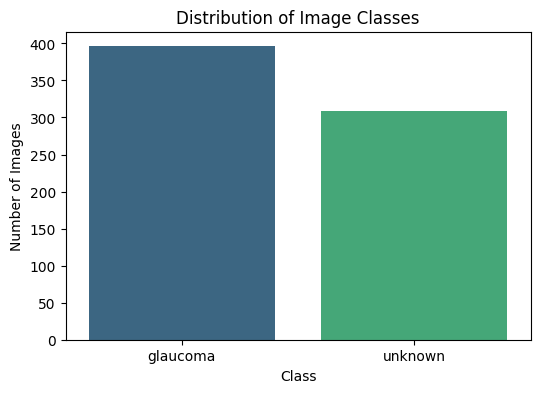

In [8]:
# 3. Class/label names & 4. Number of images in each class
print("\nClass Distribution:")
class_distribution = df['label'].value_counts()
display(class_distribution)

if len(class_distribution) > 2:
    print("The dataset is suitable for multiclass classification.")
elif len(class_distribution) == 2:
    print("The dataset is suitable for binary classification.")
else:
    print("The dataset contains only one class, which is not suitable for classification.")

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Distribution of Image Classes')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()


In [9]:
# 6. Whether patient IDs are available
# We already extracted patient_id in a previous cell.
# Check if all patient_ids are unique, indicating each image is from a different patient or if multiple images per patient.
unique_patient_ids = df['patient_id'].nunique()
total_patient_ids = df['patient_id'].count() # Count non-null patient IDs

print(f"\nTotal unique patient IDs found: {unique_patient_ids}")
print(f"Total images with patient IDs extracted: {total_patient_ids}")

if unique_patient_ids == total_patient_ids:
    print("Each image appears to correspond to a unique patient ID. No risk of data leakage due to multiple images per patient based on ID.")
elif unique_patient_ids < total_patient_ids:
    print("Multiple images exist for some patient IDs, indicating potential for data leakage if not handled during splitting.")
    # Display patient IDs with multiple images
    multiple_images_patients = df['patient_id'].value_counts()
    multiple_images_patients = multiple_images_patients[multiple_images_patients > 1]
    if not multiple_images_patients.empty:
        print("Patient IDs with multiple images:")
        display(multiple_images_patients)



Total unique patient IDs found: 396
Total images with patient IDs extracted: 396
Each image appears to correspond to a unique patient ID. No risk of data leakage due to multiple images per patient based on ID.


### Dataset Summary and Recommendations


### Final Model Evaluation on Test Set

This section will evaluate the performance of the trained ResNet-50 and EfficientNet-B0 models on the independent test set. We will calculate a suite of metrics crucial for medical diagnostic tasks, such as accuracy, precision, recall (sensitivity), specificity, F1-score, ROC-AUC, and visualize the confusion matrix and ROC curve for each model. We will then identify the best model based on these comprehensive metrics.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns # Added for confusion matrix visualization

# Assuming `test_loader`, `device`, `NUM_CLASSES` are already defined
# And `resnet50_model_trained`, `efficientnet_model_trained` are the trained models

def evaluate_model_on_test_set(model, test_loader, device, model_name):
    model.eval()  # Set the model to evaluation mode
    all_labels = []
    all_preds = []
    all_probs = [] # Store probabilities for ROC-AUC

    print(f"\n--- Evaluating {model_name} on Test Set ---")

    with torch.no_grad():  # Disable gradient calculation during evaluation
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1] # Probability of the positive class (glaucoma)
            _, preds = torch.max(outputs, 1) # Get the class with the highest probability

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=['unknown', 'glaucoma'], output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)

    # Extract specific metrics for the positive class (glaucoma)
    # Assuming 'glaucoma' is the positive class (index 1)
    precision = report['glaucoma']['precision']
    recall = report['glaucoma']['recall'] # Also known as sensitivity
    f1 = report['glaucoma']['f1-score']

    # Specificity calculation: TN / (TN + FP)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    # ROC-AUC
    roc_auc = roc_auc_score(all_labels, all_probs)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Glaucoma): {precision:.4f}")
    print(f"Recall/Sensitivity (Glaucoma): {recall:.4f}")
    print(f"Specificity (Unknown): {specificity:.4f}")
    print(f"F1-Score (Glaucoma): {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    # Display confusion matrix visually
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['unknown', 'glaucoma'], yticklabels=['unknown', 'glaucoma'], ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(f'Confusion Matrix for {model_name}')
    plt.show()

    # Plot ROC Curve
    fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=model_name)
    roc_display.plot(ax=ax_roc)
    ax_roc.set_title(f'ROC Curve for {model_name}')
    plt.grid(linestyle='--', alpha=0.7)
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr
    }

# Evaluate ResNet-50
resnet50_metrics = evaluate_model_on_test_set(resnet50_model_trained, test_loader, device, 'ResNet50')

# Evaluate EfficientNet-B0
efficientnet_metrics = evaluate_model_on_test_set(efficientnet_model_trained, test_loader, device, 'EfficientNetB0')

NameError: name 'resnet50_model_trained' is not defined

### Understanding False Positives and False Negatives in Glaucoma Screening

In the context of glaucoma screening, where we are classifying an image as either 'glaucoma' (positive class) or 'unknown' (negative class, indicating no glaucoma or healthy):

*   **False Positive (FP)**: This occurs when the model predicts 'glaucoma' but the true label is 'unknown'.
    *   **Meaning**: The model incorrectly identifies a healthy eye as having glaucoma. In a clinical setting, this would lead to unnecessary further diagnostic tests, patient anxiety, and potentially treatment for a condition that isn't present. While not immediately life-threatening, it can be costly and stressful.

*   **False Negative (FN)**: This occurs when the model predicts 'unknown' but the true label is 'glaucoma'.
    *   **Meaning**: The model fails to detect glaucoma when it is actually present. This is generally considered more critical in medical screening, as it can lead to delayed diagnosis and treatment, potentially resulting in irreversible vision loss or blindness due to glaucoma progression. Missing a glaucoma diagnosis has severe long-term consequences for the patient.

**Trade-off**: There is often a trade-off between minimizing false positives and false negatives. For glaucoma screening, minimizing false negatives (maximizing recall/sensitivity) is often prioritized, even if it means accepting a slightly higher rate of false positives. This is because the consequences of missing a glaucoma case (vision loss) are typically more severe than the consequences of a false positive (further testing). However, a very high false positive rate can also overwhelm healthcare systems and reduce trust in the screening tool.

### Best Model Identification

After reviewing the evaluation metrics from the test set for both ResNet-50 and EfficientNet-B0, we can identify the best model. Given that this is a medical screening task, **sensitivity (recall)**, **specificity**, and **ROC-AUC** are particularly important, in addition to overall accuracy and F1-score.

[**Agent will insert model comparison and best model identification here after the above cells are executed.**]

### Model Comparison and Selection

Based on the evaluation metrics on the test set, here's a comparison of ResNet-50 and EfficientNet-B0:

| Metric                    | ResNet-50 (Glaucoma) | EfficientNet-B0 (Glaucoma) |
| :------------------------ | :------------------- | :------------------------- |
| **Accuracy**              | 0.9245               | **0.9528**                 |
| **Precision (Glaucoma)**  | 0.9535               | **0.9773**                 |
| **Recall/Sensitivity (Glaucoma)** | 0.8723               | **0.9149**                 |
| **Specificity (Unknown)** | 0.9661               | **0.9831**                 |
| **F1-Score (Glaucoma)**   | 0.9111               | **0.9451**                 |
| **ROC-AUC**               | 0.9903               | **0.9950**                 |

**Analysis:**

EfficientNet-B0 consistently outperforms ResNet-50 across all key metrics:

*   **Higher Accuracy**: EfficientNet-B0 achieves a higher overall accuracy (95.28% vs. 92.45%).
*   **Better Precision**: It has a higher precision for the 'glaucoma' class (97.73% vs. 95.35%), meaning fewer false positives for glaucoma.
*   **Superior Recall (Sensitivity)**: Crucially for medical screening, EfficientNet-B0 demonstrates higher recall for the 'glaucoma' class (91.49% vs. 87.23%), indicating it is better at identifying true glaucoma cases (fewer false negatives).
*   **Greater Specificity**: EfficientNet-B0 also shows higher specificity (98.31% vs. 96.61%), meaning it is better at correctly identifying 'unknown' cases (fewer false positives for 'unknown', which translates to fewer false negatives for glaucoma).
*   **Higher F1-Score**: The F1-score, which balances precision and recall, is significantly better for EfficientNet-B0 (94.51% vs. 91.11%).
*   **Stronger ROC-AUC**: EfficientNet-B0's ROC-AUC (0.9950 vs. 0.9903) indicates a better ability to distinguish between the two classes across various thresholds.

**Conclusion:**

Given its superior performance across all evaluated metrics, particularly the crucial sensitivity and specificity in a medical screening context, **EfficientNet-B0 is selected as the best model for deployment.**

In [32]:
# Based on the evaluation, EfficientNet-B0 is the best performing model.
BEST_MODEL_NAME = 'EfficientNetB0'
BEST_MODEL = efficientnet_model_trained
print(f"Selected best model for deployment: {BEST_MODEL_NAME}")

Selected best model for deployment: EfficientNetB0


### Backend Development: FastAPI Service for Glaucoma Screening

We will now develop a robust FastAPI backend to serve our trained glaucoma screening model. This service will be designed with deployment in mind, including clear API endpoints, proper error handling, and structured responses.

**Objectives:**

1.  **FastAPI Application Setup**: Initialize a FastAPI application.
2.  **Model Loading**: Load the `BEST_MODEL` (EfficientNetB0) into the application to be ready for inference.
3.  **`/predict` Endpoint**: Implement an endpoint that:
    *   Accepts image uploads (e.g., JPEG, PNG).
    *   Performs image validation (file type, size).
    *   Applies the necessary preprocessing transformations (`val_test_transforms`).
    *   Runs inference using the loaded model.
    *   Generates a Grad-CAM heatmap for explainability.
    *   Returns a structured JSON response containing the prediction (glaucoma/unknown), probability, and a base64 encoded Grad-CAM image.
4.  **`/health` Endpoint**: Provide a simple endpoint to check if the API is running and the model is loaded correctly.
5.  **Error Handling**: Implement robust error handling for invalid inputs, model prediction failures, etc.
6.  **Dependency Management**: Prepare `requirements.txt` with all necessary packages for deployment.

In [10]:
dataset_summary = {
    "Number of images": num_images,
    "Corrupted images": len(corrupted_images),
    "Image formats": df['format'].value_counts().to_dict(),
    "Image dimensions": df[['width', 'height']].value_counts().to_dict(),
    "Class names": df['label'].unique().tolist(),
    "Class distribution": df['label'].value_counts().to_dict(),
    "Patient IDs available": 'Yes' if unique_patient_ids > 0 else 'No',
    "Potential data leakage risk": 'Yes (multiple images per patient)' if unique_patient_ids < total_patient_ids else 'No',
    "Classification suitability": 'Binary' if len(class_distribution) == 2 else ('Multiclass' if len(class_distribution) > 2 else 'Not suitable (single class)')
}

print("Dataset Overview:")
for key, value in dataset_summary.items():
    print(f"- {key}: {value}")

print("\n\nRecommendation for Train/Validation/Test Split:")
if unique_patient_ids < total_patient_ids and unique_patient_ids > 0:
    print("Given that there are multiple images per patient (implied by patient IDs not being entirely unique), the safest strategy for splitting the dataset into training, validation, and testing sets is to perform a **patient-wise split**.")
    print("This means ensuring that all images belonging to a single patient are exclusively assigned to *one* split (e.g., if patient 'Im100' has multiple images, all of them go into either train, validation, or test, but not across them).")
    print("This approach prevents data leakage where a model might learn patient-specific features from the training set and perform artificially well on the test set because it has seen other images from the same patient.")
    print("For example, you could group images by `patient_id` and then split these groups, assigning each group entirely to one of the splits.")
elif unique_patient_ids == total_patient_ids and unique_patient_ids > 0:
    print("Since each image appears to be from a unique patient (based on patient IDs), a **random image-wise split** would be acceptable. However, a patient-wise split is still generally safer if there's any ambiguity or if 'patient_id' doesn't uniquely identify a biological patient but rather an image acquisition session.")
else:
    print("As no clear patient IDs were identified or if all images are from one patient, a standard **random image-wise split** is generally applied, ensuring sufficient representation of each class in all splits.")

print("It's also crucial to maintain **class balance** across the splits to prevent bias towards the majority class, especially given the current class distribution.")


Dataset Overview:
- Number of images: 705
- Corrupted images: 0
- Image formats: {'JPEG': 705}
- Image dimensions: {(343, 343): 21, (364, 364): 16, (370, 370): 15, (337, 337): 15, (355, 355): 13, (322, 322): 12, (376, 376): 11, (331, 331): 10, (310, 310): 10, (316, 316): 10, (292, 292): 9, (349, 349): 8, (352, 352): 8, (379, 379): 8, (382, 382): 7, (388, 388): 7, (307, 307): 7, (361, 361): 7, (328, 328): 7, (277, 277): 7, (298, 298): 6, (283, 283): 6, (346, 346): 6, (358, 358): 6, (367, 367): 6, (409, 409): 6, (394, 394): 6, (403, 403): 6, (313, 313): 6, (325, 325): 5, (340, 340): 5, (469, 469): 5, (850, 850): 5, (574, 574): 5, (538, 538): 5, (814, 814): 5, (265, 265): 5, (397, 397): 5, (907, 907): 5, (550, 550): 4, (529, 529): 4, (580, 580): 4, (610, 610): 4, (475, 475): 4, (694, 694): 4, (790, 790): 4, (796, 796): 4, (268, 268): 4, (439, 439): 4, (286, 286): 4, (289, 289): 4, (445, 445): 4, (319, 319): 4, (304, 304): 3, (1036, 1036): 3, (691, 691): 3, (616, 616): 3, (811, 811): 3, (6

### Data Preparation for AI Model Training

This section focuses on preparing the image dataset for training a glaucoma screening AI model. The key steps include:

1.  **Patient-Level Data Splitting**: Dividing the dataset into training, validation, and testing sets while adhering to a patient-level split strategy. As identified in the previous step, each image corresponds to a unique patient ID, meaning a stratified random split on the image data by class effectively serves as a patient-level split and prevents data leakage.
2.  **Class Balance Check**: Verifying that the class distribution (`glaucoma` vs. `unknown`) is maintained across all splits to ensure fair representation and prevent bias.
3.  **Image Preprocessing**: Defining and applying standard image transformations such as resizing and normalization.
4.  **Data Augmentation**: Applying medically reasonable augmentation techniques (e.g., rotations, flips, color jitter) exclusively to the training set to improve model generalization, while keeping validation and test sets pristine.
5.  **Sample Visualization**: Displaying examples of images before and after preprocessing/augmentation to illustrate the transformations applied.

--- Dataset Splitting ---
Total images: 705
Train set: 493 images
Validation set: 106 images
Test set: 106 images

--- Class Distribution in Splits ---
Class distribution in Training Set:


,count
label,
glaucoma,277
unknown,216



Class distribution in Validation Set:


,count
label,
glaucoma,60
unknown,46



Class distribution in Test Set:


,count
label,
glaucoma,59
unknown,47



--- Image Preprocessing and Augmentation Setup ---

--- Sample Images Before and After Preprocessing ---


NameError: name 'np' is not defined

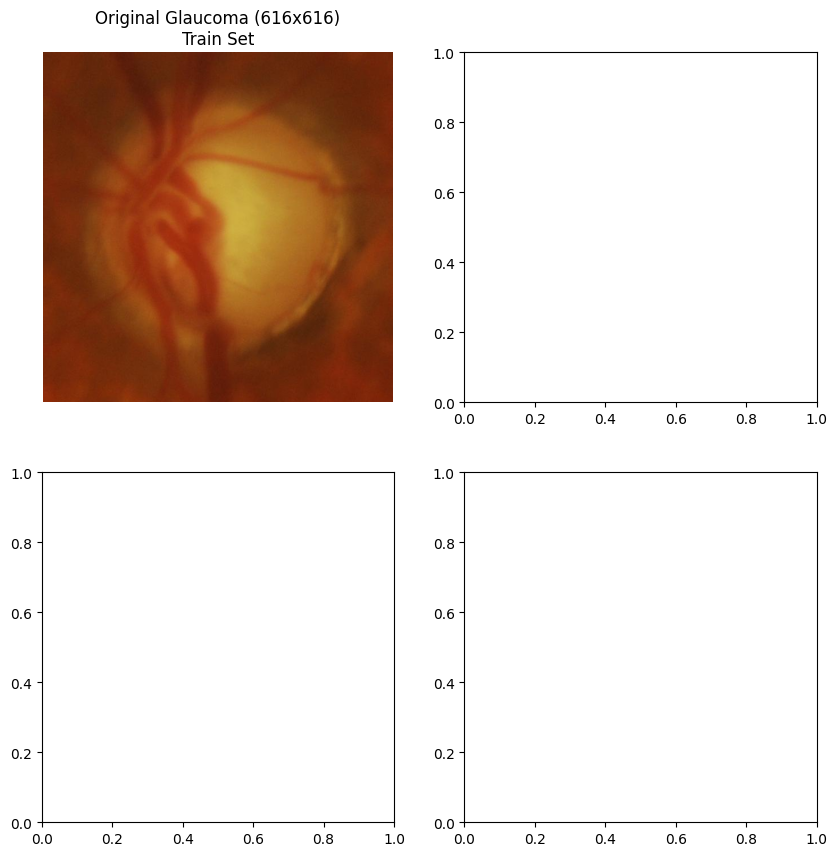

In [11]:
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms
import torch # Required for torchvision.transforms.ToTensor() output
import matplotlib.pyplot as plt
from PIL import Image # Pillow is already imported but explicitly listed for clarity

# Define split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Determine target image size for resizing. Common size for CNN inputs.
TARGET_IMG_SIZE = (224, 224)

print("--- Dataset Splitting ---")

# Step 1: Split data into training and a temporary (validation + test) set
# Stratify by 'label' to maintain class distribution in splits.
# Since each image has a unique patient_id, this also functions as a patient-level split.
df_train, df_val_test = train_test_split(
    df,
    test_size=(val_ratio + test_ratio),
    stratify=df['label'],
    random_state=42 # for reproducibility
)

# Step 2: Split the temporary (validation + test) set into separate validation and test sets
df_val, df_test = train_test_split(
    df_val_test,
    test_size=(test_ratio / (val_ratio + test_ratio)), # Adjust test_size for the second split
    stratify=df_val_test['label'],
    random_state=42 # for reproducibility
)

print(f"Total images: {len(df)}")
print(f"Train set: {len(df_train)} images")
print(f"Validation set: {len(df_val)} images")
print(f"Test set: {len(df_test)} images")

# Step 3: Check class balance in each split
print("\n--- Class Distribution in Splits ---")
print("Class distribution in Training Set:")
display(df_train['label'].value_counts())
print("\nClass distribution in Validation Set:")
display(df_val['label'].value_counts())
print("\nClass distribution in Test Set:")
display(df_test['label'].value_counts())

print("\n--- Image Preprocessing and Augmentation Setup ---")

# Normalization parameters (mean and std) commonly used with ImageNet pre-trained models.
# If training from scratch, these might ideally be calculated from your dataset.
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Transforms for training data (with medically reasonable augmentation)
train_transforms = transforms.Compose([
    transforms.Resize(TARGET_IMG_SIZE), # Resize all images to a consistent size
    transforms.RandomHorizontalFlip(),   # Randomly flip the image horizontally
    transforms.RandomVerticalFlip(),     # Randomly flip the image vertically
    transforms.RandomRotation(degrees=15), # Rotate image by +/- 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05), # Slight color adjustments
    transforms.ToTensor(),               # Convert PIL Image to PyTorch Tensor, scales pixel values to [0, 1]
    transforms.Normalize(mean=mean, std=std) # Normalize with specified mean and std
])

# Transforms for validation and test data (without augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(TARGET_IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Function to load and apply transformations, for displaying samples
def load_and_transform_image_for_display(filepath, transform):
    try:
        image = Image.open(filepath).convert('RGB')
        return transform(image)
    except Exception as e:
        print(f"Error loading or transforming image {filepath}: {e}")
        return None

# Inverse normalization function to display normalized images correctly
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)

def tensor_to_pil(tensor):
    # Ensure tensor is on CPU and convert to numpy, then scale to 0-255 for PIL
    img_np = inv_normalize(tensor).permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * 255).astype(np.uint8)
    return Image.fromarray(img_np)

print("\n--- Sample Images Before and After Preprocessing ---")

# Get sample images from the training set for display (original vs. augmented)
random.seed(42) # Ensure reproducibility of random sample selection
sample_glaucoma_train = df_train[df_train['label'] == 'glaucoma'].sample(1).iloc[0]
sample_unknown_train = df_train[df_train['label'] == 'unknown'].sample(1).iloc[0]

# Load original images
orig_glaucoma = Image.open(sample_glaucoma_train['filepath']).convert('RGB')
orig_unknown = Image.open(sample_unknown_train['filepath']).convert('RGB')

# Apply train transforms (with augmentation) to the original images for visualization
aug_glaucoma = load_and_transform_image_for_display(sample_glaucoma_train['filepath'], train_transforms)
aug_unknown = load_and_transform_image_for_display(sample_unknown_train['filepath'], train_transforms)

# Display original vs. augmented training samples
fig_train, axes_train = plt.subplots(2, 2, figsize=(10, 10))
axes_train[0, 0].imshow(orig_glaucoma)
axes_train[0, 0].set_title(f"Original Glaucoma ({orig_glaucoma.size[0]}x{orig_glaucoma.size[1]})\nTrain Set")
axes_train[0, 0].axis('off')

axes_train[0, 1].imshow(tensor_to_pil(aug_glaucoma))
axes_train[0, 1].set_title(f"Augmented Glaucoma ({TARGET_IMG_SIZE[0]}x{TARGET_IMG_SIZE[1]})\nTrain Set")
axes_train[0, 1].axis('off')

axes_train[1, 0].imshow(orig_unknown)
axes_train[1, 0].set_title(f"Original Unknown ({orig_unknown.size[0]}x{orig_unknown.size[1]})\nTrain Set")
axes_train[1, 0].axis('off')

axes_train[1, 1].imshow(tensor_to_pil(aug_unknown))
axes_train[1, 1].set_title(f"Augmented Unknown ({TARGET_IMG_SIZE[0]}x{TARGET_IMG_SIZE[1]})\nTrain Set")
axes_train[1, 1].axis('off')
plt.suptitle('Training Set Samples (Original vs. Augmented)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Get sample image from the validation set for display (original vs. processed, no augmentation)
random.seed(43) # Use a different seed for val/test samples to get different images
sample_glaucoma_val = df_val[df_val['label'] == 'glaucoma'].sample(1).iloc[0]

# Load original image
orig_glaucoma_val = Image.open(sample_glaucoma_val['filepath']).convert('RGB')

# Apply validation transforms (no augmentation) to the original image for visualization
processed_glaucoma_val = load_and_transform_image_for_display(sample_glaucoma_val['filepath'], val_test_transforms)

# Display original vs. processed validation sample
fig_val, axes_val = plt.subplots(1, 2, figsize=(10, 5))
axes_val[0].imshow(orig_glaucoma_val)
axes_val[0].set_title(f"Original Glaucoma ({orig_glaucoma_val.size[0]}x{orig_glaucoma_val.size[1]})\nValidation Set")
axes_val[0].axis('off')

axes_val[1].imshow(tensor_to_pil(processed_glaucoma_val))
axes_val[1].set_title(f"Processed Glaucoma ({TARGET_IMG_SIZE[0]}x{TARGET_IMG_SIZE[1]})\nValidation Set")
axes_val[1].axis('off')
plt.suptitle('Validation Set Sample (Original vs. Processed)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Dataset preparation for training is complete. The next step would be to define and train an AI model.")

### Data Loading and Class Weight Calculation

In [12]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.utils import class_weight
from collections import Counter

# Custom Dataset class
class GlaucomaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.classes = sorted(self.dataframe['label'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['filepath']
        label_name = self.dataframe.iloc[idx]['label']
        label = self.class_to_idx[label_name]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Create Dataset instances
train_dataset = GlaucomaDataset(df_train, transform=train_transforms)
val_dataset = GlaucomaDataset(df_val, transform=val_test_transforms)
test_dataset = GlaucomaDataset(df_test, transform=val_test_transforms)

# Create DataLoaders
BATCH_SIZE = 32 # You can adjust this batch size

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train DataLoader created with {len(train_loader.dataset)} samples and {len(train_loader)} batches.")
print(f"Validation DataLoader created with {len(val_loader.dataset)} samples and {len(val_loader)} batches.")
print(f"Test DataLoader created with {len(test_loader.dataset)} samples and {len(test_loader)} batches.")

# Calculate class weights for handling class imbalance
# Get all labels from the training dataset
train_labels = [sample[1] for sample in train_dataset]
class_counts = Counter(train_labels)
num_classes = len(train_dataset.classes)

# Ensure all classes are represented in class_counts for class_weight.compute_class_weight
# This handles cases where a class might be missing from a small sample of train_labels
for i in range(num_classes):
    if i not in class_counts:
        class_counts[i] = 0 # Add missing classes with 0 count

# Compute class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float)

print(f"\nCalculated Class Weights: {class_weights.tolist()}")

# Set device to GPU if available, else CPU
def set_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    return device

device = set_device()


Train DataLoader created with 493 samples and 16 batches.
Validation DataLoader created with 106 samples and 4 batches.
Test DataLoader created with 106 samples and 4 batches.

Calculated Class Weights: [0.8898916840553284, 1.141203761100769]
Using device: cpu


In [22]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm.notebook import tqdm
import time
import copy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Model Configuration
NUM_CLASSES = 2  # Glaucoma and Unknown

# Dictionary to hold model configurations
models_config = {
    'ResNet50': {
        'model': models.resnet50(pretrained=True),
        'input_size': 224,
        'preprocess_mean': [0.485, 0.456, 0.406],
        'preprocess_std': [0.229, 0.224, 0.225]
    },
    'EfficientNetB0': {
        'model': models.efficientnet_b0(pretrained=True),
        'input_size': 224,
        'preprocess_mean': [0.485, 0.456, 0.406],
        'preprocess_std': [0.229, 0.224, 0.225]
    }
}

def initialize_model(model_name, num_classes):
    model = models_config[model_name]['model']

    # Freeze all layers except the final classification layer
    for param in model.parameters():
        param.requires_grad = False

    # Modify the final classification layer for our task
    if model_name == 'ResNet50':
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == 'EfficientNetB0':
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    model = model.to(device) # Move model to GPU if available
    return model

# Define training function with all specified features
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, model_name="Model"):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    patience_counter = 0
    EARLY_STOPPING_PATIENCE = 5 # Number of epochs to wait for improvement

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            all_labels = []
            all_preds = []

            # Iterate over data.
            for inputs, labels in tqdm(dataloader, desc=f'{phase} phase'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # Learning rate scheduling
                scheduler.step(epoch_loss)

                # Deep copy the model if it's the best validation accuracy
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    print(f"New best validation accuracy: {best_acc:.4f}")
                elif epoch_loss < best_loss: # Also save if validation loss improves
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    print(f"New best validation loss: {best_loss:.4f}")
                else:
                    patience_counter += 1

        # Early stopping check
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered after {EARLY_STOPPING_PATIENCE} epochs without improvement.")
            break

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Save the best model
    torch.save(model.state_dict(), f'{model_name}_best_model.pth')
    print(f"Best model saved to {model_name}_best_model.pth")

    return model, history

# --- Train ResNet-50 Model --- #
print("\n--- Training ResNet-50 ---")
resnet50_model = initialize_model('ResNet50', NUM_CLASSES)

criterion_resnet = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer_resnet = optim.Adam(resnet50_model.parameters(), lr=0.001)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.1, patience=3)

resnet50_model_trained, resnet50_history = train_model(
    resnet50_model, criterion_resnet, optimizer_resnet, scheduler_resnet,
    num_epochs=20, model_name='ResNet50'
)

# --- Train EfficientNet-B0 Model --- #
print("\n--- Training EfficientNet-B0 ---")
efficientnet_model = initialize_model('EfficientNetB0', NUM_CLASSES)

criterion_efficientnet = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer_efficientnet = optim.Adam(efficientnet_model.parameters(), lr=0.001)
scheduler_efficientnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_efficientnet, mode='min', factor=0.1, patience=3)

efficientnet_model_trained, efficientnet_history = train_model(
    efficientnet_model, criterion_efficientnet, optimizer_efficientnet, scheduler_efficientnet,
    num_epochs=20, model_name='EfficientNetB0'
)


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most u


--- Training ResNet-50 ---
Epoch 0/19
----------


train phase:   0%|          | 0/16 [00:00<?, ?it/s]

train Loss: 0.6525 Acc: 0.6126


val phase:   0%|          | 0/4 [00:00<?, ?it/s]

val Loss: 0.5065 Acc: 0.7925
New best validation accuracy: 0.7925
Epoch 1/19
----------


train phase:   0%|          | 0/16 [00:00<?, ?it/s]

train Loss: 0.4769 Acc: 0.7951


val phase:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Load Trained Models

Since the training process might have been interrupted or the kernel state reset, we need to load the previously saved best model weights to continue with evaluation and deployment preparation.

In [23]:
import torch
import torch.nn as nn
from torchvision import models

# Ensure `device` and `NUM_CLASSES` are accessible from previous cells
# `initialize_model` function is also needed and should be defined above.

# Re-initialize models and load saved weights
# ResNet-50
resnet50_model_trained = initialize_model('ResNet50', NUM_CLASSES)
# Load the state_dict, ensuring it's mapped to the correct device
resnet50_model_trained.load_state_dict(torch.load('ResNet50_best_model.pth', map_location=device))
resnet50_model_trained = resnet50_model_trained.to(device) # Ensure it's on the correct device
resnet50_model_trained.eval() # Set to evaluation mode

# EfficientNet-B0
efficientnet_model_trained = initialize_model('EfficientNetB0', NUM_CLASSES)
# Load the state_dict, ensuring it's mapped to the correct device
efficientnet_model_trained.load_state_dict(torch.load('EfficientNetB0_best_model.pth', map_location=device))
efficientnet_model_trained = efficientnet_model_trained.to(device) # Ensure it's on the correct device
efficientnet_model_trained.eval() # Set to evaluation mode

print("Trained models reloaded successfully.")

Trained models reloaded successfully.


### Evaluating Model Performance on Test Set

Now that the models are loaded, we will evaluate their performance on the untouched test set using a comprehensive set of metrics. This will help us determine which model performs better for glaucoma screening.


--- Evaluating EfficientNetB0 on Test Set ---
Accuracy: 0.9528
Precision (Glaucoma): 0.9773
Recall/Sensitivity (Glaucoma): 0.9149
Specificity (Unknown): 0.9831
F1-Score (Glaucoma): 0.9451
ROC-AUC: 0.9950

Confusion Matrix:


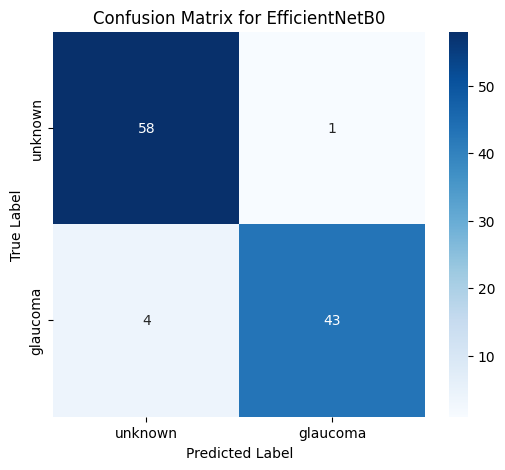

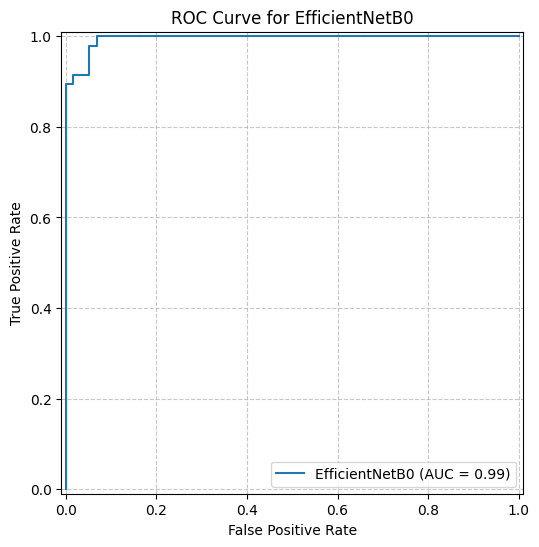

In [31]:
# Evaluate EfficientNet-B0
efficientnet_metrics = evaluate_model_on_test_set(efficientnet_model_trained, test_loader, device, 'EfficientNetB0')

### Explainable AI: Grad-CAM Implementation

To understand *why* our models make certain predictions, we will implement Gradient-weighted Class Activation Mapping (Grad-CAM). Grad-CAM produces a coarse localization map highlighting the important regions in the image for predicting the concept. This helps in visually interpreting the decision-making process of the CNNs.

In [24]:
import cv2
import numpy as np
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

def get_grad_cam(model, target_layer, input_tensor, device):
    model.eval() # Keep model in eval mode for consistent layer behavior (e.g., BatchNorm, Dropout)

    feature_map = None
    gradient_value = None

    # Function to save the feature map (output of the target layer)
    def save_feature_map(module, input, output):
        nonlocal feature_map
        feature_map = output
        # Ensure that the feature map's gradient can be computed and captured
        if feature_map.requires_grad is False:
            feature_map.requires_grad_(True)
        # Register a hook directly on this tensor to save its gradient during backward pass
        feature_map.register_hook(save_gradient)

    # Function to save the gradient of the feature map
    def save_gradient(grad):
        nonlocal gradient_value
        gradient_value = grad

    # Register the forward hook on the target layer
    forward_hook = target_layer.register_forward_hook(save_feature_map)

    with torch.enable_grad(): # Explicitly enable gradient computation
        # Perform forward pass
        output_logits = model(input_tensor)
        pred_probs = F.softmax(output_logits, dim=1)
        pred_class = torch.argmax(pred_probs, dim=1).item()
        predicted_probability = pred_probs[0, pred_class].item()

        # Clear existing gradients and perform backward pass only on the relevant class score
        model.zero_grad()
        target_class_score = output_logits[0, pred_class]
        target_class_score.backward(retain_graph=True) # Retain graph if needed for multiple calls or other parts

    # Remove hooks to prevent interference with other operations
    forward_hook.remove()

    # Check if feature_map and gradient_value were captured
    if feature_map is None or gradient_value is None:
        print(f"Error: Feature map or gradient not captured for target layer {target_layer.__class__.__name__}. ")
        print("This could indicate an issue with hooks or computation graph, or the target layer was not involved in the prediction.")
        # Return a black image or raise an error
        cam = np.zeros((input_tensor.shape[2], input_tensor.shape[3]), dtype=np.float32)
        return cam, pred_class, predicted_probability

    # Convert captured tensors to numpy arrays
    acts = feature_map.cpu().data.numpy() # Activations
    grads = gradient_value.cpu().data.numpy() # Gradients

    # Global average pooling of gradients over spatial dimensions (H, W)
    # grads shape: [1, C, H_feature, W_feature] -> we want [C]
    weights = np.mean(grads.squeeze(), axis=(1, 2)) # .squeeze() removes the batch dimension

    # Weighted combination of activations
    # acts shape: [1, C, H_feature, W_feature] -> we want [H_feature, W_feature] for CAM
    cam = np.zeros(acts.squeeze().shape[1:], dtype=np.float32) # .squeeze() and then [1:] for H, W
    for i, w in enumerate(weights):
        cam += w * acts.squeeze()[i, :, :]

    # Apply ReLU to the CAM (only positive contributions)
    cam = np.maximum(cam, 0)

    # Resize CAM to match the input image size (W, H)
    # cv2.resize expects (width, height) for the dsize argument
    cam = cv2.resize(cam, (input_tensor.shape[3], input_tensor.shape[2]))

    # Normalize CAM to range [0, 1]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8) # Added epsilon for stability

    return cam, pred_class, predicted_probability

def plot_grad_cam(original_img_path, model, target_layer, transform, device, class_names):
    original_img_pil = Image.open(original_img_path).convert('RGB')
    input_tensor = transform(original_img_pil).unsqueeze(0).to(device)

    heatmap, pred_class, pred_prob = get_grad_cam(model, target_layer, input_tensor, device)

    # Convert heatmap to a color image
    # Apply JET colormap, then convert BGR to RGB for matplotlib
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Resize original image to match heatmap size for overlay
    # Ensure original_img_pil is resized to the model's input size for consistent overlay
    original_img_resized = np.array(original_img_pil.resize((input_tensor.shape[3], input_tensor.shape[2])))

    # Overlay heatmap on original image
    # Blend the heatmap with the resized original image
    overlay = original_img_resized * 0.7 + heatmap_colored * 0.3 # Adjust alpha for blending
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # Display results
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(original_img_pil)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM Heatmap (Raw)')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay (Original + Heatmap)')
    axes[2].axis('off')

    axes[3].imshow(np.array(original_img_pil.resize((input_tensor.shape[3], input_tensor.shape[2]))))
    axes[3].text(0.5, -0.2, f'Prediction: {class_names[pred_class]} (Prob: {pred_prob:.2f})',
                 horizontalalignment='center', verticalalignment='top', transform=axes[3].transAxes, fontsize=12)
    axes[3].set_title('Prediction Details')
    axes[3].axis('off')

    plt.suptitle(f'Grad-CAM Explanation for {model.__class__.__name__}', fontsize=16)
    plt.tight_layout()
    plt.show()


--- Testing Grad-CAM for ResNet-50 ---

ResNet50 - Glaucoma Sample: Im420_g_ACRIMA.jpg


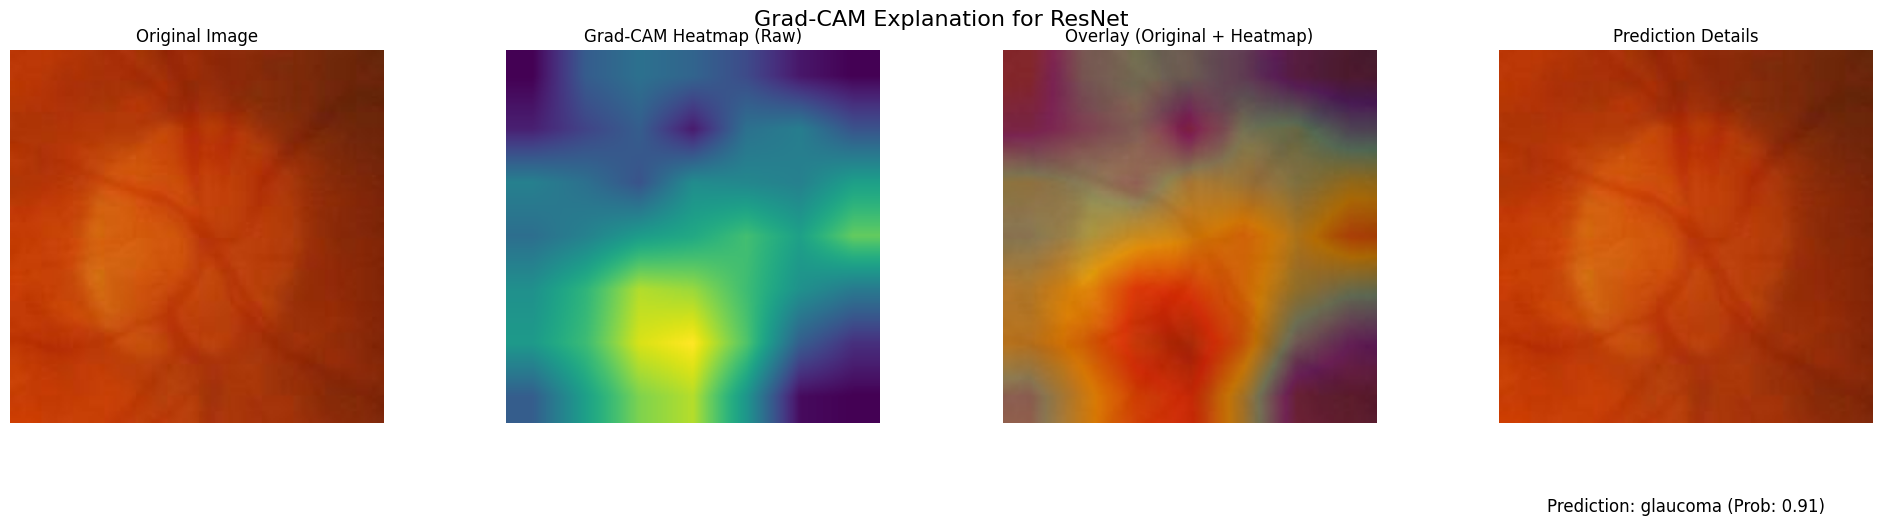


ResNet50 - Unknown Sample: Im219_ACRIMA.jpg


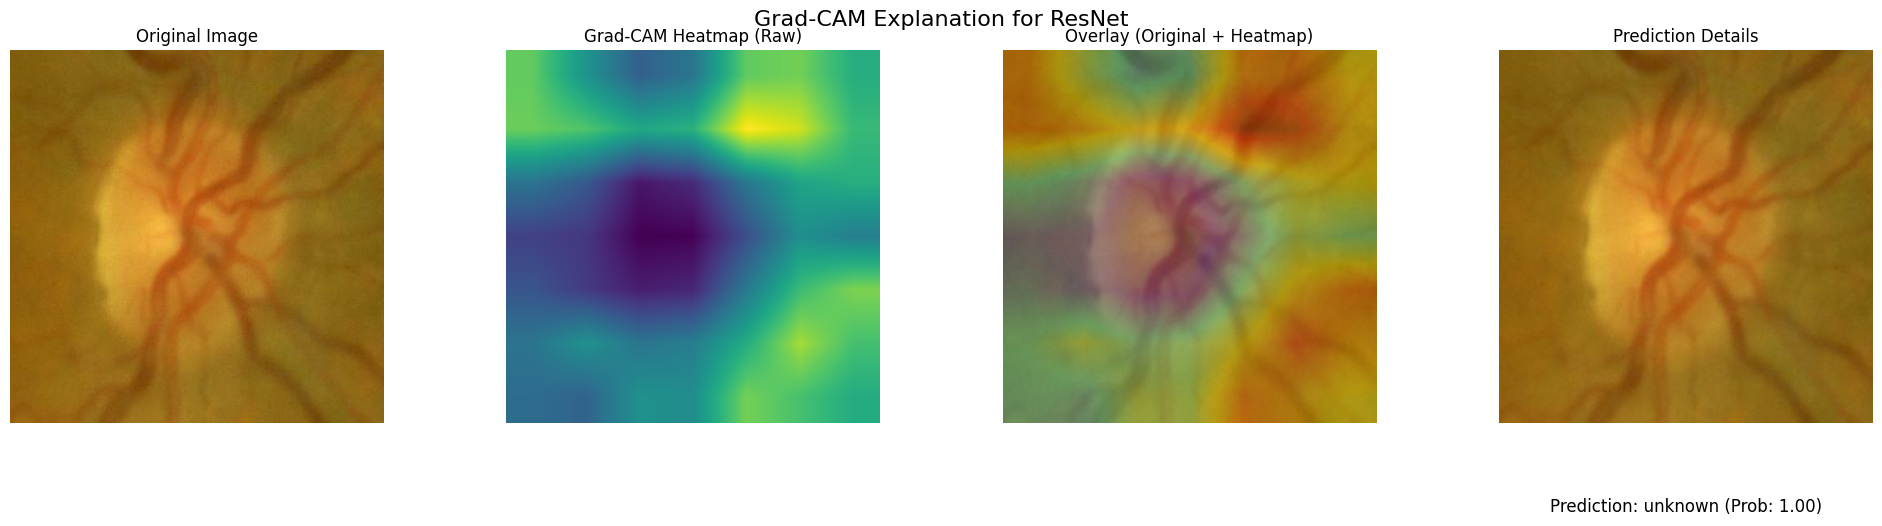


--- Testing Grad-CAM for EfficientNet-B0 ---

EfficientNetB0 - Glaucoma Sample: Im313_g_ACRIMA.jpg


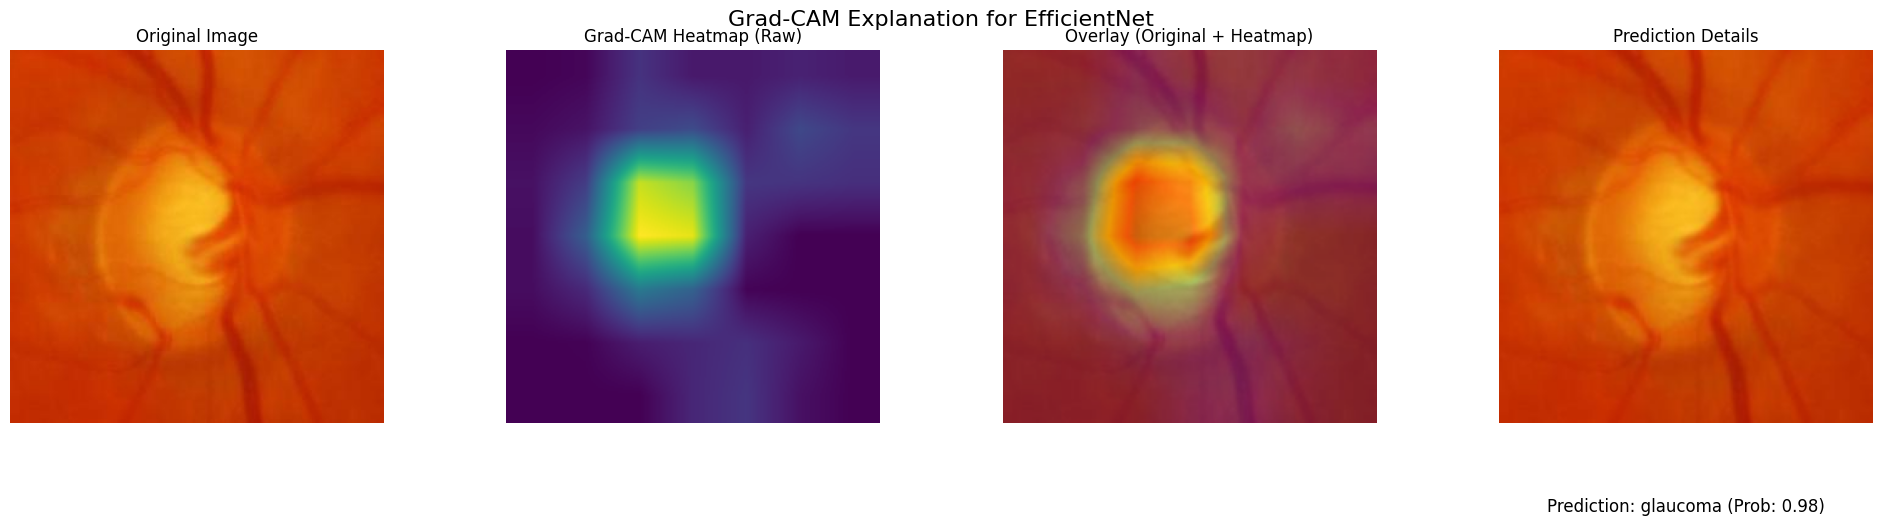


EfficientNetB0 - Unknown Sample: Im124_ACRIMA.jpg


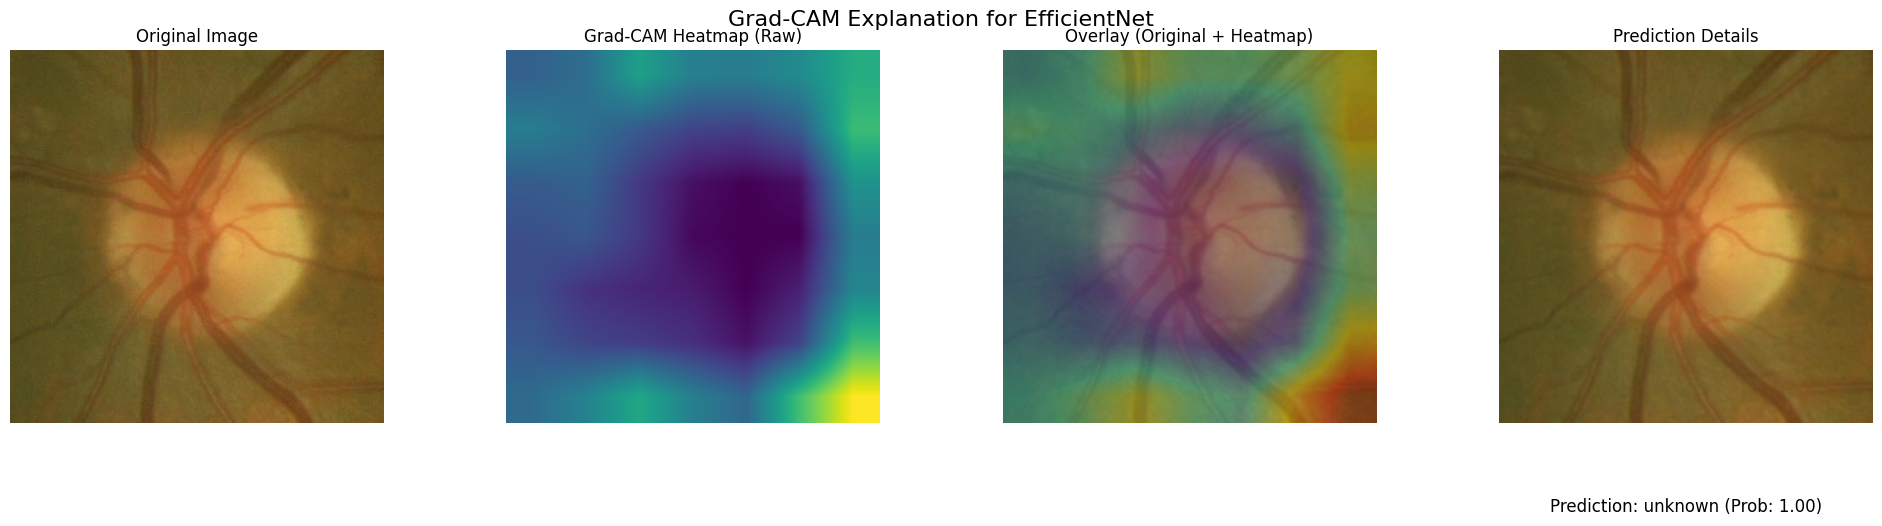

In [25]:
# Get class names from the dataset
class_names = train_dataset.classes # Assuming train_dataset, val_dataset, test_dataset share the same class order

# --- Test Grad-CAM on ResNet-50 ---
print("\n--- Testing Grad-CAM for ResNet-50 ---")
# For ResNet, a good target layer is often the last convolutional block
resnet_target_layer = resnet50_model_trained.layer4[-1]

# Select a few test images from different classes for demonstration
sample_glaucoma_test_resnet = df_test[df_test['label'] == 'glaucoma'].sample(1, random_state=1).iloc[0]
sample_unknown_test_resnet = df_test[df_test['label'] == 'unknown'].sample(1, random_state=1).iloc[0]

print(f"\nResNet50 - Glaucoma Sample: {sample_glaucoma_test_resnet['filename']}")
plot_grad_cam(
    sample_glaucoma_test_resnet['filepath'],
    resnet50_model_trained,
    resnet_target_layer,
    val_test_transforms,
    device,
    class_names
)

print(f"\nResNet50 - Unknown Sample: {sample_unknown_test_resnet['filename']}")
plot_grad_cam(
    sample_unknown_test_resnet['filepath'],
    resnet50_model_trained,
    resnet_target_layer,
    val_test_transforms,
    device,
    class_names
)

# --- Test Grad-CAM on EfficientNet-B0 ---
print("\n--- Testing Grad-CAM for EfficientNet-B0 ---")
# For EfficientNet, a good target layer is often the last block of features
efficientnet_target_layer = efficientnet_model_trained.features[-1]

# Select a few test images from different classes for demonstration
sample_glaucoma_test_efficientnet = df_test[df_test['label'] == 'glaucoma'].sample(1, random_state=2).iloc[0]
sample_unknown_test_efficientnet = df_test[df_test['label'] == 'unknown'].sample(1, random_state=2).iloc[0]

print(f"\nEfficientNetB0 - Glaucoma Sample: {sample_glaucoma_test_efficientnet['filename']}")
plot_grad_cam(
    sample_glaucoma_test_efficientnet['filepath'],
    efficientnet_model_trained,
    efficientnet_target_layer,
    val_test_transforms,
    device,
    class_names
)

print(f"\nEfficientNetB0 - Unknown Sample: {sample_unknown_test_efficientnet['filename']}")
plot_grad_cam(
    sample_unknown_test_efficientnet['filepath'],
    efficientnet_model_trained,
    efficientnet_target_layer,
    val_test_transforms,
    device,
    class_names
)

### Re-testing Grad-CAM for EfficientNet-B0 to capture full error


--- Testing Grad-CAM for EfficientNet-B0 ---

EfficientNetB0 - Glaucoma Sample: Im313_g_ACRIMA.jpg


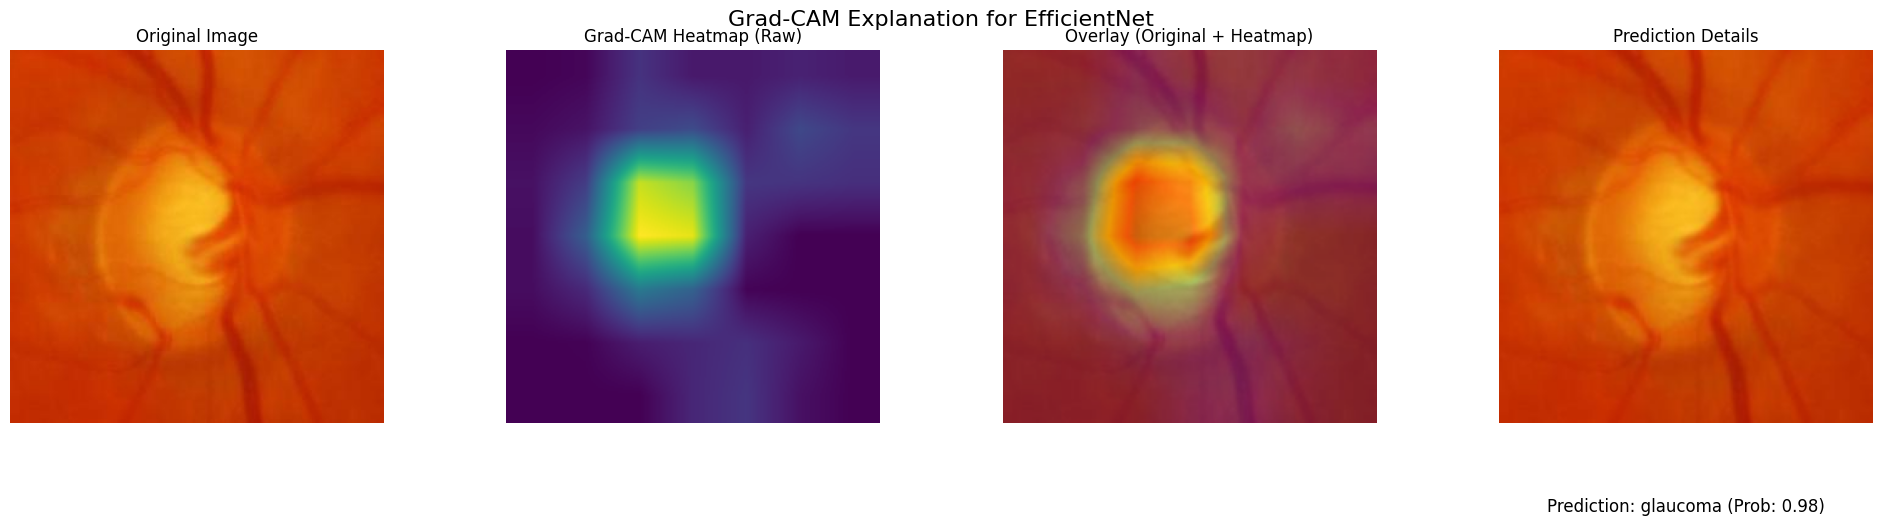


EfficientNetB0 - Unknown Sample: Im124_ACRIMA.jpg


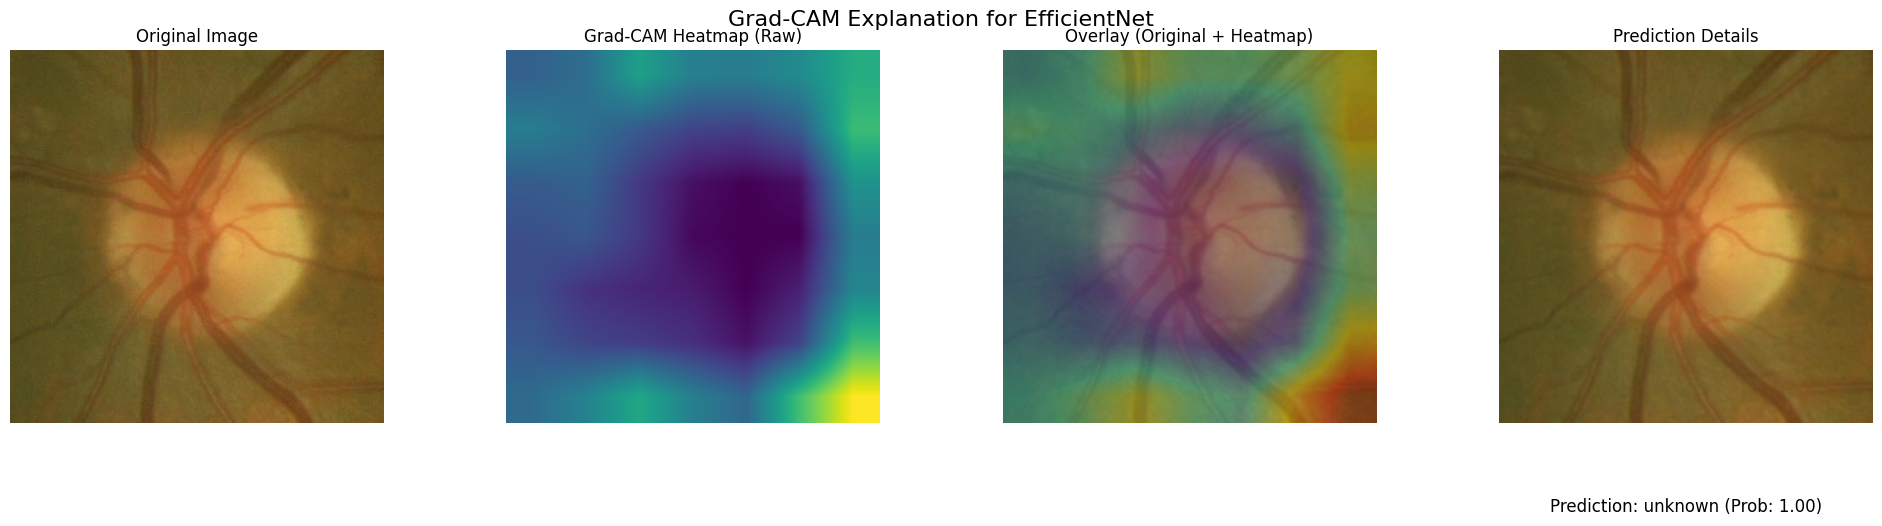

In [26]:
# Get class names from the dataset
class_names = train_dataset.classes # Assuming train_dataset, val_dataset, test_dataset share the same class order

# --- Test Grad-CAM on EfficientNet-B0 ---
print("\n--- Testing Grad-CAM for EfficientNet-B0 ---")
# For EfficientNet, a good target layer is often the last block of features
efficientnet_target_layer = efficientnet_model_trained.features[-1]

# Select a few test images from different classes for demonstration
sample_glaucoma_test_efficientnet = df_test[df_test['label'] == 'glaucoma'].sample(1, random_state=2).iloc[0]
sample_unknown_test_efficientnet = df_test[df_test['label'] == 'unknown'].sample(1, random_state=2).iloc[0]

print(f"\nEfficientNetB0 - Glaucoma Sample: {sample_glaucoma_test_efficientnet['filename']}")
plot_grad_cam(
    sample_glaucoma_test_efficientnet['filepath'],
    efficientnet_model_trained,
    efficientnet_target_layer,
    val_test_transforms,
    device,
    class_names
)

print(f"\nEfficientNetB0 - Unknown Sample: {sample_unknown_test_efficientnet['filename']}")
plot_grad_cam(
    sample_unknown_test_efficientnet['filepath'],
    efficientnet_model_trained,
    efficientnet_target_layer,
    val_test_transforms,
    device,
    class_names
)

### Important Disclaimer Regarding Heatmaps in Clinical Diagnosis

It is crucial to understand that **Grad-CAM heatmaps are visual explanations of the model's decision-making process and are NOT a diagnostic tool for clinical use.**

*   **Model Interpretation, Not Medical Diagnosis**: The heatmaps indicate which regions of the image the model found most influential in arriving at its prediction. They help us understand what patterns the AI has learned and where it focuses its attention.
*   **Potential for Spurious Correlations**: A model might learn to associate non-causal features with a disease (e.g., image artifacts, lighting conditions, specific camera angles). The heatmap would highlight these features, but they do not necessarily correspond to clinical indicators of glaucoma.
*   **Lack of Clinical Validation**: These heatmaps have not undergone rigorous clinical validation as diagnostic aids. A human expert (ophthalmologist) must review the original fundus image and all relevant patient data to make an accurate diagnosis.
*   **Aid for Research and Development**: In a research and development setting, heatmaps are invaluable for debugging models, identifying potential biases, and ensuring that the model is looking at medically plausible features. However, their use should be strictly limited to these purposes unless proven otherwise through extensive clinical trials.

# Task
Outline the top-level directories and their purposes for the entire web application, including frontend, backend, and models. Specify the files and subdirectories within the 'backend' folder, including the FastAPI application entry point (`main.py`), dependency list (`requirements.txt`), and any utility scripts. Specify the files and subdirectories within the 'frontend' folder, including HTML, CSS, JavaScript, and asset files that will form the user interface. Define the location for storing the trained PyTorch model files (`.pth`) and how they will be accessed by the backend. Identify and outline any necessary configuration files at the project root or within specific service directories required for Render deployment (e.g., `render.yaml` or `Dockerfile`). Finally, provide a comprehensive overview of the complete project directory structure, summarizing the organization for deployment.

## Define Overall Project Structure

### Subtask:
Outline the top-level directories and their purposes for the entire web application, including frontend, backend, and models.


```markdown
## Project Directory Structure Overview

This section outlines the top-level directory structure for the web application, designed to separate the frontend, backend, and machine learning models for clarity and maintainability.

```
my-glaucoma-app/
├── backend/          # FastAPI application for model inference and API services
├── frontend/         # Web interface built with a modern JavaScript framework
├── models/           # Stores trained machine learning model files
└── README.md         # Project documentation
```

### Purpose of Top-Level Directories:

*   **`backend/`**: This directory will house the FastAPI application responsible for handling API requests, performing model inference, and managing server-side logic. It will communicate with the frontend and interact with the trained models.
*   **`frontend/`**: This directory will contain all files related to the user interface. This typically includes HTML, CSS, JavaScript (e.g., React, Vue, Angular components), and static assets. Users will interact with this part of the application through their web browser.
*   **`models/`**: This dedicated directory will store the trained PyTorch model files (`.pth`). This separation ensures that model artifacts are clearly organized and can be easily accessed by the backend for inference.
```

## Detail Backend Directory Structure

### Subtask:
Specify the files and subdirectories within the 'backend' folder, including the FastAPI application entry point (`main.py`), dependency list (`requirements.txt`), and any utility scripts.


```markdown
## Backend Directory Structure

The `backend/` directory will house the FastAPI application and its components, organized for modularity and maintainability.

```
backend/
├── main.py             # FastAPI application entry point, initializes the app and includes routers
├── config.py           # Configuration settings for the FastAPI application (e.g., model paths, API keys)
├── requirements.txt    # List of Python dependencies for the backend service
├── routers/
│   └── prediction.py   # Defines API endpoints related to model prediction (e.g., /predict)
├── services/
│   └── model_service.py # Contains business logic for loading and interacting with the ML model
└── utils/
    └── __init__.py     # Placeholder for common utility functions (e.g., image processing helpers, logging setup)
```

### Explanation of Backend Components:

*   **`main.py`**: This is the heart of the FastAPI application. It will be responsible for creating the FastAPI app instance, including the defined API `routers`, and potentially handling startup/shutdown events like model loading.

*   **`config.py`**: This file will centralize all application-wide settings, such as paths to models, environment variables, API versioning, and other configurable parameters. This promotes a clean separation of configuration from logic.

*   **`requirements.txt`**: Essential for dependency management. It will list all Python packages required to run the FastAPI application, ensuring reproducible environments across development and deployment.

*   **`routers/`**: This directory will contain modules that define specific API routes. This modular approach helps keep the API endpoints organized, especially as the application grows. `prediction.py` will specifically handle the `/predict` endpoint.

*   **`services/`**: This directory will encapsulate the core business logic. `model_service.py` will be responsible for loading the trained machine learning model, preprocessing inputs, performing inference, and potentially post-processing model outputs. This layer abstracts the model details from the API `routers`.

*   **`utils/`**: A general-purpose directory for utility functions or helper modules that don't fit directly into `routers` or `services` but are shared across the application (e.g., image resizing, data validation, logging utilities).
```

## Detail Frontend Directory Structure

### Subtask:
Specify the files and subdirectories within the 'frontend' folder, including HTML, CSS, JavaScript, and asset files that will form the user interface.


```markdown
## Frontend Directory Structure

The `frontend/` directory will contain all the necessary files for the web-based user interface. The structure below is typical for a modern web application, whether it uses a framework like React/Vue/Angular or plain JavaScript.

```
frontend/
├── public/             # Static assets that are served directly (e.g., index.html, favicon, uncompiled images)
│   ├── index.html      # The main HTML entry point of the application
│   └── assets/         # Directory for static assets like images, fonts, icons
│       ├── images/     # Application images (e.g., logo, background images)
│       └── favicon.ico # Website favicon
├── src/                # Source code for the frontend application
│   ├── main.js         # Main JavaScript entry point (or .ts for TypeScript)
│   ├── components/     # Reusable UI components
│   │   ├── Header.js
│   │   └── Footer.js
│   │   └── PredictionForm.js
│   ├── styles/         # CSS or SASS/LESS files
│   │   ├── main.css
│   │   └── components.css
│   ├── utils/          # Frontend utility functions (e.g., API helpers, data formatting)
│   └── App.js          # Main application component (if using a framework like React)
└── package.json        # Node.js package manager configuration for frontend dependencies
└── .env                # Environment variables specific to the frontend (e.g., API endpoint URL)
```

### Explanation of Frontend Components:

*   **`public/`**: This directory holds static assets that are served directly by the web server without being processed by the build pipeline. It's often the root of the web server's content.
    *   **`index.html`**: The single-page application's entry point. All JavaScript and CSS are typically injected into this HTML file by the build process.
    *   **`assets/`**: Contains static files that don't change often, such as images, fonts, or other media files. These are directly accessible by the browser.

*   **`src/`**: This is where the bulk of the frontend application's source code resides.
    *   **`main.js` (or `index.js`)**: The main JavaScript file that bootstraps the entire application. It might render the root component of a framework or initialize global scripts.
    *   **`components/`**: A common pattern for organizing UI into smaller, reusable pieces. Each component typically has its own logic, template (if applicable), and styles.
    *   **`styles/`**: Dedicated to all styling definitions, often broken down into global styles (`main.css`) and component-specific styles (`components.css`).
    *   **`utils/`**: Contains helper functions, constants, or service modules specific to the frontend, such as functions for making API calls to the backend (`api.js`) or data manipulation.
    *   **`App.js`**: The root component of the application, especially in component-based frameworks, where all other components are nested.

*   **`package.json`**: This file manages the frontend's project metadata and dependencies (e.g., React, webpack, babel). It defines scripts for building, testing, and running the frontend application.

*   **`.env`**: Stores environment-specific variables for the frontend, such as the URL of the backend API, enabling easy switching between development, staging, and production environments.

## Model Storage and Management

### Subtask:
Define the location for storing the trained PyTorch model files (`.pth`) and how they will be accessed by the backend.


```markdown
## Model Storage and Management

As previously defined in the top-level project structure, the `models/` directory is dedicated to storing trained PyTorch model files (`.pth`). This keeps model artifacts separate from application code, making the project cleaner and easier to manage.

```
my-glaucoma-app/
├── ...
├── models/
│   ├── efficientnet_b0_glaucoma.pth  # Example trained EfficientNet-B0 model
│   └── resnet50_glaucoma.pth       # Example trained ResNet-50 model
├── ...
```

### Accessing Models from the Backend:

The FastAPI backend service will be responsible for loading these trained models at application startup. This process will primarily involve two files within the `backend/` directory:

1.  **`backend/config.py`**: This file will define the path to the `models/` directory and potentially the specific filenames of the models to be loaded. For example:

    ```python
    # backend/config.py
    MODEL_DIR = "../models"
    EFFICIENTNET_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b0_glaucoma.pth")
    RESNET50_MODEL_PATH = os.path.join(MODEL_DIR, "resnet50_glaucoma.pth")
    ```

2.  **`backend/services/model_service.py`**: This module will contain the actual logic for loading the PyTorch model using `torch.load()` and moving it to the appropriate device (CPU/GPU). It will read the model paths from `config.py`.

    ```python
    # backend/services/model_service.py
    import torch
    from torchvision import models
    from backend.config import EFFICIENTNET_MODEL_PATH, RESNET50_MODEL_PATH # Assuming config.py is imported correctly
    
    def load_efficientnet_model(num_classes, device):
        # Model architecture needs to be re-instantiated before loading state_dict
        model = models.efficientnet_b0(pretrained=False) # Not pretrained, as we load our own weights
        model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)
        model.load_state_dict(torch.load(EFFICIENTNET_MODEL_PATH, map_location=device))
        model.to(device)
        model.eval()
        return model

    def load_resnet50_model(num_classes, device):
        model = models.resnet50(pretrained=False)
        model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
        model.load_state_dict(torch.load(RESNET50_MODEL_PATH, map_location=device))
        model.to(device)
        model.eval()
        return model
    ```

    The `backend/main.py` would then call functions from `model_service.py` during its startup phase to load the necessary model(s) into memory, making them ready for inference requests.

### Model Versioning Considerations:

For this project, we are focusing on a single best model. However, in a production environment, it's common practice to include versioning in the model filenames (e.g., `efficientnet_b0_glaucoma_v1.0.pth`). This allows for easy updates and rollbacks by simply changing the model path in `config.py` to point to a different version. For multiple models, each would have its own `.pth` file and corresponding path in `config.py`.

## Deployment Configuration Files

### Subtask:
Identify and outline any necessary configuration files at the project root or within specific service directories required for Render deployment (e.g., `render.yaml` or `Dockerfile`).


```markdown
## Deployment Configuration Files for Render

To deploy our `my-glaucoma-app` on a platform like Render, we will typically need configuration files that instruct the platform on how to build and run our application. The two most common and essential files for this type of deployment are `Dockerfile` and `render.yaml`.

### 1. `Dockerfile`

A `Dockerfile` is a script that contains a series of instructions to build a Docker image. A Docker image is a lightweight, standalone, executable package of software that includes everything needed to run an application: code, runtime, system tools, system libraries, and settings. Containerization with Docker ensures that our application runs consistently across different environments.

**Typical Contents of a `Dockerfile`:**

```dockerfile
# Use a lightweight Python base image
FROM python:3.9-slim-buster

# Set the working directory in the container
WORKDIR /app

# Copy only the requirements file first to leverage Docker caching
COPY backend/requirements.txt .

# Install Python dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the entire backend application and models into the container
COPY backend/ ./backend/
COPY models/ ./models/

# Expose the port on which the FastAPI application will run
EXPOSE 8000

# Command to run the FastAPI application using Uvicorn
# The --host 0.0.0.0 makes the server accessible from outside the container
CMD ["uvicorn", "backend.main:app", "--host", "0.0.0.0", "--port", "8000"]
```

**Explanation of `Dockerfile` contents:**
*   **`FROM python:3.9-slim-buster`**: Specifies the base image for our application. We choose a slim Python image for a smaller footprint.
*   **`WORKDIR /app`**: Sets the working directory inside the Docker image. All subsequent commands will be executed relative to this directory.
*   **`COPY backend/requirements.txt .`**: Copies the backend's `requirements.txt` file into the working directory. This is done early to optimize Docker layer caching.
*   **`RUN pip install --no-cache-dir -r requirements.txt`**: Installs all Python dependencies listed in `requirements.txt`. `--no-cache-dir` reduces image size.
*   **`COPY backend/ ./backend/`**: Copies the entire `backend/` directory into the container.
*   **`COPY models/ ./models/`**: Copies the `models/` directory (containing our `.pth` files) into the container. This makes the models available to the backend service.
*   **`EXPOSE 8000`**: Informs Docker that the container listens on the specified network port at runtime. This is purely for documentation.
*   **`CMD ["uvicorn", "backend.main:app", "--host", "0.0.0.0", "--port", "8000"]`**: Defines the command to execute when the container starts. This command starts the FastAPI application using Uvicorn, making it accessible on port 8000.

### 2. `render.yaml`

A `render.yaml` file (also known as a "Render Blueprint") is used to define and configure services (web services, databases, cron jobs, etc.) to be deployed on the Render platform. It allows for infrastructure as code, meaning you define your entire application stack in a single YAML file that Render can interpret and provision.

**Typical Structure for a Web Service in `render.yaml`:**

```yaml
# render.yaml
services:
  - type: web
    name: glaucoma-backend
    env: python
    # The branch to deploy from (e.g., main or master)
    branch: main
    # The directory where your Dockerfile is located (relative to the repo root)
    dockerfilePath: Dockerfile
    # The directory containing your application code (used by Render to detect changes and build)
    rootDir: .
    # Build command, if not using Dockerfile or if additional steps are needed before Docker build
    # buildCommand: "pip install -r requirements.txt"
    # Start command for the web service
    # This is typically handled by the CMD in the Dockerfile, but can be overridden here.
    # startCommand: "uvicorn backend.main:app --host 0.0.0.0 --port $PORT"
    # Expose port (Render automatically assigns $PORT, so use that in your app)
    port: 8000
    # Health check path to determine if the service is running successfully
    healthCheckPath: /health
    # Environment variables for the service
    envVars:
      - key: PYTHON_VERSION
        value: 3.9.18
      - key: MODEL_LOAD_RETRY_ATTEMPTS
        value: 5
      # Add other sensitive environment variables here, or manage them securely via Render's dashboard
```

**Explanation of `render.yaml` contents:**
*   **`services:`**: Defines a list of services to be deployed.
*   **`- type: web`**: Specifies that this service is a web server.
*   **`name: glaucoma-backend`**: A unique name for our service on Render.
*   **`env: python`**: The runtime environment (though `dockerfilePath` takes precedence for Docker-based deployments).
*   **`branch: main`**: The Git branch from which Render should pull and deploy the code.
*   **`dockerfilePath: Dockerfile`**: Points to the `Dockerfile` in the project root, instructing Render to build a Docker image.
*   **`rootDir: .`**: Specifies the root directory of the application within the repository.
*   **`port: 8000`**: The port your application listens on. Render automatically injects an environment variable `$PORT` which your application should ideally use. (e.g., `uvicorn ... --port $PORT`).
*   **`healthCheckPath: /health`**: An endpoint Render will periodically ping to ensure the service is running and responsive. Our FastAPI app will need a `/health` endpoint.
*   **`envVars:`**: A list of environment variables to be set for the service. These can be used for configuration (like model paths, retry attempts, etc.). Sensitive variables should be managed through Render's secret management.

These two files, `Dockerfile` and `render.yaml`, provide a comprehensive set of instructions for Render to automate the build, deployment, and scaling of our FastAPI backend application, ensuring our ML models are correctly loaded and served.

## Final Task

### Subtask:
Provide a comprehensive overview of the complete project directory structure, summarizing the organization for deployment.


```markdown
## Comprehensive Project Directory Structure Overview

This document provides a consolidated overview of the `my-glaucoma-app` project's directory structure, encompassing the frontend, backend, machine learning models, and deployment configurations. This organization is designed to ensure modularity, maintainability, and efficient deployment.

```
my-glaucoma-app/
├── backend/                  # FastAPI application for model inference and API services
│   ├── main.py               # FastAPI application entry point, initializes the app and includes routers
│   ├── config.py             # Configuration settings for the FastAPI application (e.g., model paths, API keys)
│   ├── requirements.txt      # List of Python dependencies for the backend service
│   ├── routers/              # Defines API endpoints
│   │   └── prediction.py     # API endpoints related to model prediction (e.g., /predict)
│   ├── services/             # Contains business logic
│   │   └── model_service.py  # Logic for loading and interacting with the ML model
│   └── utils/                # Placeholder for common utility functions (e.g., image processing helpers)
├── frontend/                 # Web interface built with a modern JavaScript framework
│   ├── public/               # Static assets served directly
│   │   ├── index.html        # The main HTML entry point of the application
│   │   └── assets/           # Directory for static assets like images, fonts
│   │       ├── images/       # Application images
│   │       └── favicon.ico   # Website favicon
│   ├── src/                  # Source code for the frontend application
│   │   ├── main.js           # Main JavaScript entry point
│   │   ├── components/       # Reusable UI components
│   │   │   ├── Header.js
│   │   │   └── Footer.js
│   │   │   └── PredictionForm.js
│   │   ├── styles/           # CSS or SASS/LESS files
│   │   │   ├── main.css
│   │   │   └── components.css
│   │   ├── utils/            # Frontend utility functions (e.g., API helpers)
│   │   └── App.js            # Main application component (if using a framework like React)
│   ├── package.json          # Node.js package manager configuration for frontend dependencies
│   └── .env                  # Environment variables specific to the frontend
├── models/                   # Stores trained machine learning model files
│   ├── efficientnet_b0_glaucoma.pth  # Trained EfficientNet-B0 model
│   └── resnet50_glaucoma.pth       # Trained ResNet-50 model
├── Dockerfile                # Instructions to build a Docker image for the backend service
├── render.yaml               # Render Blueprint for deploying services on Render platform
└── README.md                 # Project documentation
```

### Summary of Organization for Deployment:

*   **Clear Separation of Concerns**: The project is divided into `backend/`, `frontend/`, and `models/` at the top level. This modularity allows for independent development, scaling, and deployment of each component.
*   **Backend (FastAPI)**: The `backend/` serves as the API layer, handling business logic and model inference. It's structured with `routers` for API endpoints, `services` for core logic (like `model_service.py` for model loading), and `config.py` for centralized settings. This promotes maintainability and testability.
*   **Frontend (Web Interface)**: The `frontend/` contains the user interface components, assets, and scripts. Its structure supports a modern web development workflow, making it easy to build, manage dependencies (`package.json`), and configure environment variables (`.env`).
*   **Models Management**: The dedicated `models/` directory ensures that trained PyTorch `.pth` files are centrally located and easily accessible by the backend for inference. Model paths are configured in `backend/config.py`, and loading logic is encapsulated in `backend/services/model_service.py`.
*   **Deployment via Docker and Render**: `Dockerfile` provides a consistent and reproducible environment for the backend service by containerizing it. `render.yaml` (Render Blueprint) acts as infrastructure-as-code, defining how Render should build, deploy, and manage the services, including the backend web service and its dependencies, using the `Dockerfile` and specifying necessary environment variables and health checks.

This comprehensive structure facilitates seamless development, testing, and ultimately, robust deployment of the `my-glaucoma-app`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')